In [1]:
# ============================================
# ИМПОРТ БИБЛИОТЕК И НАСТРОЙКИ
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Для интерактивных графиков
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook'

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [2]:
# ============================================
# ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ============================================

# Загрузка данных
try:
    df = pd.read_csv('data/SF_case_data.csv', sep=',')
    print("✅ Данные успешно загружены")
except FileNotFoundError:
    # Создание демо-данных для примера
    print("⚠️ Файл не найден. Создаю демо-данные...")
    np.random.seed(42)
    n_rows = 500000
    dates = pd.date_range('2020-01-01', '2020-03-31', freq='H')
    
    demo_data = {
        'date': np.random.choice(dates, n_rows),
        'event': np.random.choice(['app_install', 'app_start', 'registration', 
                                  'search', 'open_item', 'choose_item', 
                                  'tap_basket', 'purchase'], n_rows, 
                                 p=[0.05, 0.3, 0.1, 0.2, 0.15, 0.1, 0.05, 0.05]),
        'gender': np.random.choice(['M', 'F', None], n_rows, p=[0.4, 0.4, 0.2]),
        'os_name': np.random.choice(['iOS', 'Android'], n_rows, p=[0.4, 0.6]),
        'city': np.random.choice(['Москва', 'Санкт-Петербург', 'Новосибирск', 
                                 'Екатеринбург', 'Казань', 'Другой'], n_rows),
        'device_id': [f'device_{i}' for i in np.random.randint(1, 50000, n_rows)],
        'utm_source': np.random.choice(['yandex-direct', 'google_ads', 'vk_ads', 
                                       'instagram_ads', 'facebook_ads', 
                                       'referral', '-'], n_rows),
        'purchase_sum': np.random.exponential(500, n_rows).round(2)
    }
    df = pd.DataFrame(demo_data)

# Базовая информация о данных
print("="*60)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"Период данных: с {df['date'].min()} по {df['date'].max()}")
print(f"Количество уникальных пользователей: {df['device_id'].nunique():,}")
print(f"Количество уникальных событий: {df['event'].nunique()}")
print("\nТипы данных:")
print(df.dtypes)

# Преобразование даты
df['date'] = pd.to_datetime(df['date'])
df['date_only'] = df['date'].dt.date
df['week'] = df['date'].dt.isocalendar().week
df['day_of_week'] = df['date'].dt.day_name()

# Просмотр первых строк
print("\n" + "="*60)
print("ПЕРВЫЕ 5 СТРОК ДАННЫХ")
print("="*60)
display(df.head())

✅ Данные успешно загружены
БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 2,747,968 строк, 8 столбцов
Период данных: с 2020-01-01 по 2020-03-31
Количество уникальных пользователей: 190,884
Количество уникальных событий: 7

Типы данных:
date             object
event            object
purchase_sum    float64
os_name          object
device_id         int64
gender           object
city             object
utm_source       object
dtype: object

ПЕРВЫЕ 5 СТРОК ДАННЫХ


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,date_only,week,day_of_week
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,1,Wednesday
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads,2020-01-01,1,Wednesday
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal,2020-01-01,1,Wednesday
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads,2020-01-01,1,Wednesday
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads,2020-01-01,1,Wednesday


1. КЛЮЧЕВЫЕ ПРОДУКТОВЫЕ МЕТРИКИ (Q1 2020)

Расчет Retention Rate (альтернативный метод):
Day 1 Retention: 0.6%

Ключевые продуктовые метрики:
         Metric        Value
            DAU 8.228890e+03
            WAU 2.832807e+04
            MAU 1.908840e+05
     Stickiness 4.310938e+00
Conversion Rate 3.712988e+01
      Avg Check 7.091161e+02
     Revenue Q1 1.002570e+08
Day 1 Retention 6.468431e-01


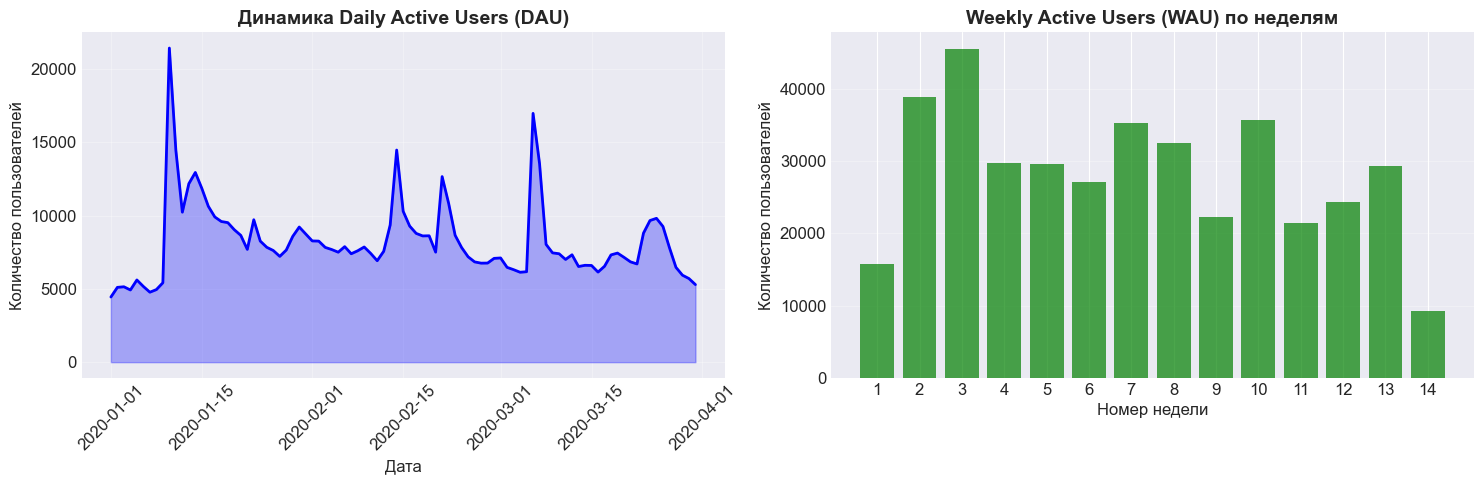


Активность по дням недели:


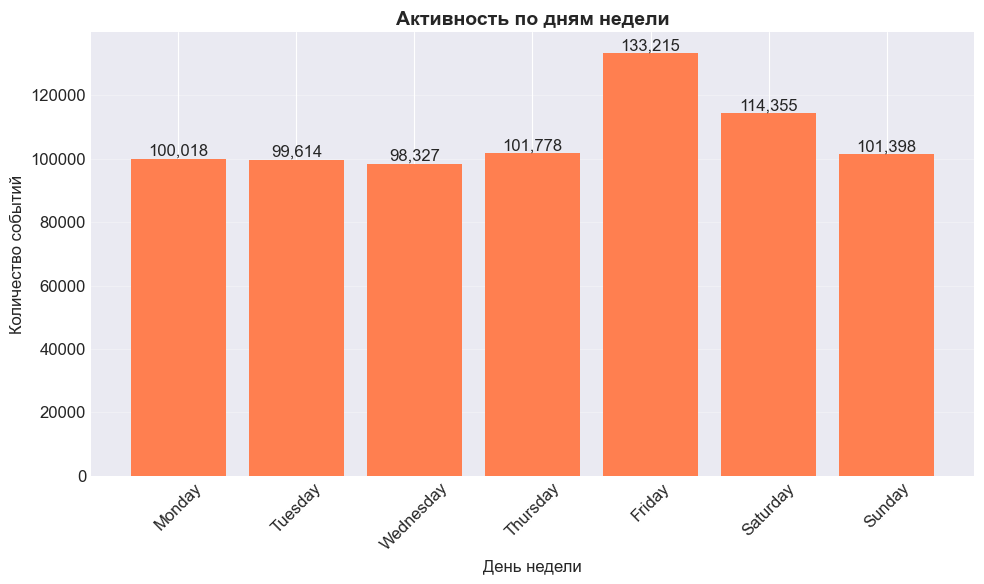

In [5]:
# ============================================
# 1. ПРОДУКТОВАЯ МЕТРИКИ И KPI
# ============================================

print("="*60)
print("1. КЛЮЧЕВЫЕ ПРОДУКТОВЫЕ МЕТРИКИ (Q1 2020)")
print("="*60)

# Рассчитываем основные метрики
metrics = {}

# 1.1. Активность пользователей
daily_active_users = df[df['event'].isin(['app_start', 'search', 'purchase'])].groupby('date_only')['device_id'].nunique()
weekly_active_users = df[df['event'].isin(['app_start', 'search', 'purchase'])].groupby('week')['device_id'].nunique()

metrics['DAU'] = daily_active_users.mean()
metrics['WAU'] = weekly_active_users.mean()
metrics['MAU'] = df[df['event'].isin(['app_start', 'search', 'purchase'])]['device_id'].nunique()

# 1.2. Коэффициент вовлеченности
stickiness = (metrics['DAU'] / metrics['MAU']) * 100 if metrics['MAU'] > 0 else 0
metrics['Stickiness'] = stickiness

# 1.3. Конверсии в покупку
total_users = df['device_id'].nunique()
purchasing_users = df[df['event'] == 'purchase']['device_id'].nunique()
conversion_rate = (purchasing_users / total_users) * 100 if total_users > 0 else 0
metrics['Conversion Rate'] = conversion_rate

# 1.4. Средний чек
avg_check = df[df['event'] == 'purchase']['purchase_sum'].mean()
metrics['Avg Check'] = avg_check

# 1.5. Выручка
revenue = df[df['event'] == 'purchase']['purchase_sum'].sum()
metrics['Revenue Q1'] = revenue

# Альтернативный расчет Retention
print("\nРасчет Retention Rate (альтернативный метод):")

# Находим пользователей, которые установили приложение
install_users = df[df['event'] == 'app_install']['device_id'].unique()

if len(install_users) > 0:
    # Находим их первые активности после установки
    retention_counts = 0
    
    for user in install_users[:1000]:  # Ограничиваем для скорости
        user_install_date = df[(df['device_id'] == user) & (df['event'] == 'app_install')]['date_only'].min()
        user_activities = df[(df['device_id'] == user) & (df['event'] == 'app_start')]['date_only']
        
        if not user_activities.empty:
            first_activity = user_activities.min()
            days_diff = (first_activity - user_install_date).days
            if 0 <= days_diff <= 1:
                retention_counts += 1
    
    day1_retention = (retention_counts / len(install_users)) * 100
    print(f"Day 1 Retention: {day1_retention:.1f}%")
    metrics['Day 1 Retention'] = day1_retention
else:
    print("Нет данных об установках для расчета Retention")
    metrics['Day 1 Retention'] = 0

# Выводим метрики
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nКлючевые продуктовые метрики:")
print(metrics_df.to_string(index=False))

# Визуализация DAU и WAU
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График DAU
axes[0].plot(daily_active_users.index, daily_active_users.values, linewidth=2, color='blue')
axes[0].set_title('Динамика Daily Active Users (DAU)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата', fontsize=12)
axes[0].set_ylabel('Количество пользователей', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(daily_active_users.index, daily_active_users.values, alpha=0.3, color='blue')

# График WAU
axes[1].bar(weekly_active_users.index.astype(str), weekly_active_users.values, color='green', alpha=0.7)
axes[1].set_title('Weekly Active Users (WAU) по неделям', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Номер недели', fontsize=12)
axes[1].set_ylabel('Количество пользователей', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Дополнительная визуализация: тепловая карта активности по неделям и дням
print("\nАктивность по дням недели:")
activity_by_day = df[df['event'] == 'app_start']['day_of_week'].value_counts()
# Упорядочиваем дни недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
activity_by_day = activity_by_day.reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(activity_by_day.index, activity_by_day.values, color='coral')
ax.set_title('Активность по дням недели', fontsize=14, fontweight='bold')
ax.set_xlabel('День недели', fontsize=12)
ax.set_ylabel('Количество событий', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. АНАЛИЗ ЭФФЕКТИВНОСТИ КАНАЛОВ ПРИВЛЕЧЕНИЯ


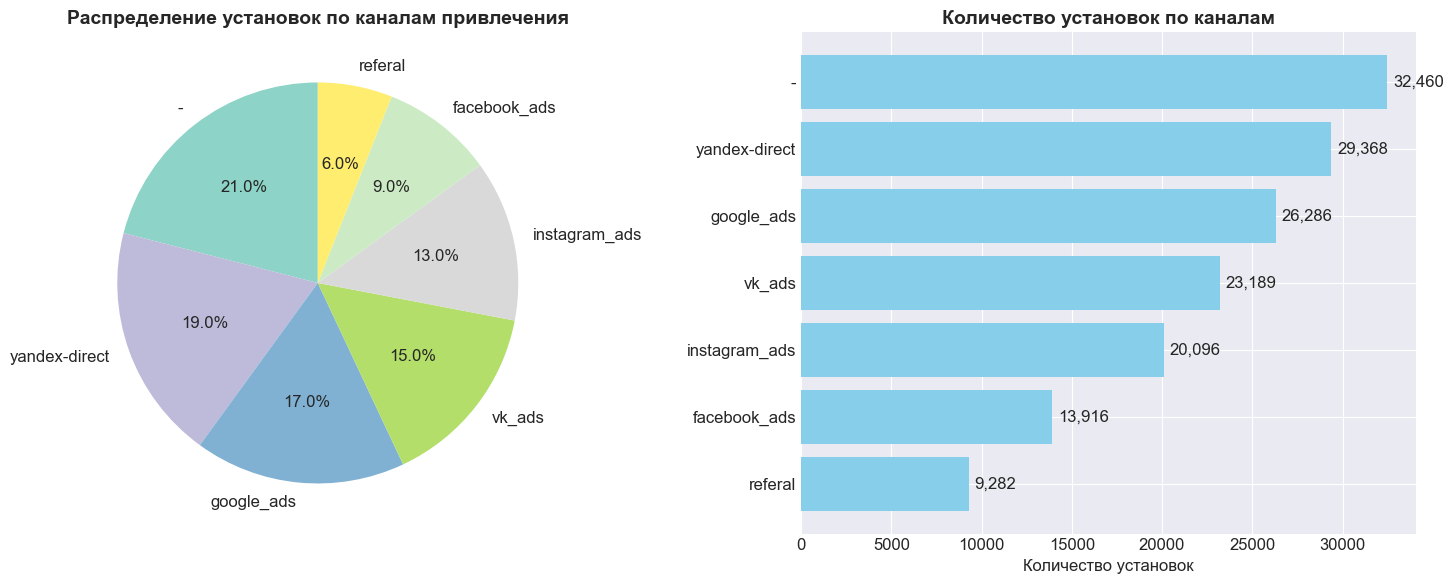


Топ-3 канала по установкам:
1. -: 32,460 установок (21.0%)
2. yandex-direct: 29,368 установок (19.0%)
3. google_ads: 26,286 установок (17.0%)

АНАЛИЗ КОНВЕРСИИ ПО КАНАЛАМ


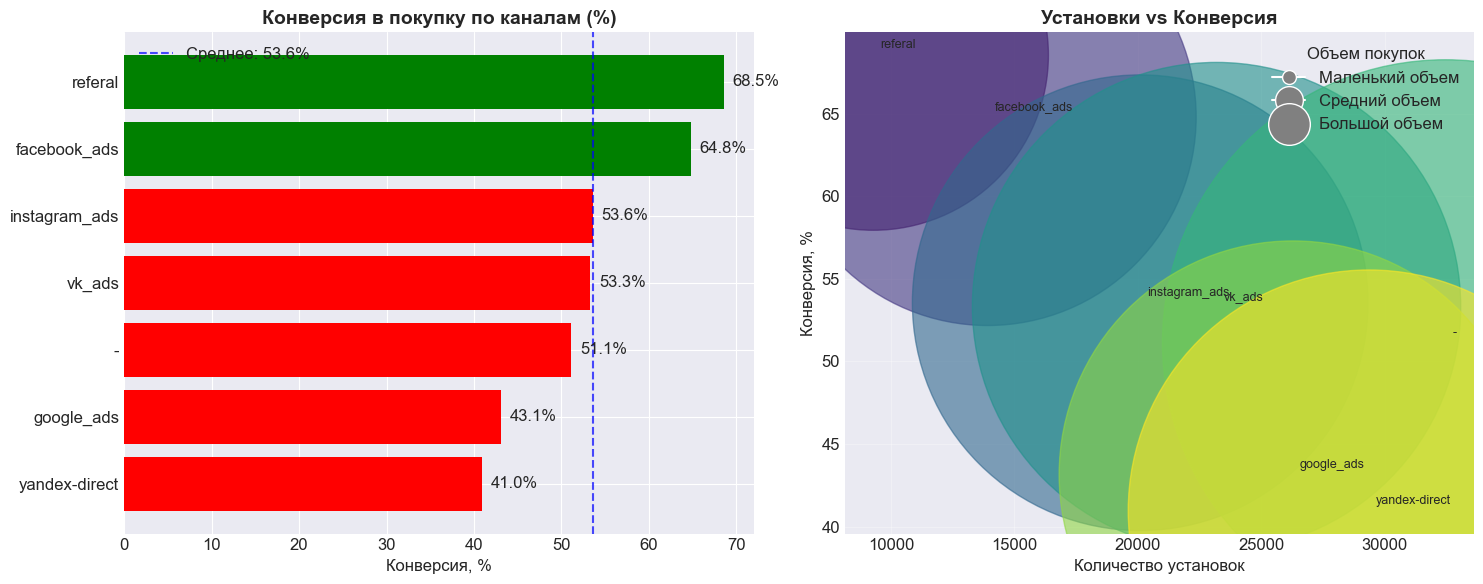


АНАЛИЗ ЭФФЕКТИВНОСТИ КАНАЛОВ (CAC & ROMI)

Сводная таблица эффективности каналов:


,Канал,Пользователи,Установки,Покупки,Выручка,Затраты,CAC,ARPU,ROMI,AOV
0,-,52273,32460,16598,21449749.5,0,0.000000,410.340893,inf,1292.309284
2,referal,15926,9282,6362,8837044.5,0,0.000000,554.881609,inf,1389.035602
1,vk_ads,34086,23189,12364,16389652.5,9553531,411.985467,480.832380,71.555967,1325.594670
5,instagram_ads,31048,20096,10762,14546969.0,8561626,426.036326,468.531596,69.908952,1351.697547
3,facebook_ads,25959,13916,9017,12249901.0,8590498,617.310865,471.894179,42.598264,1358.533991
6,yandex-direct,40712,29368,12028,13915368.0,10491707,357.249625,341.800157,32.632068,1156.914533
4,google_ads,38096,26286,11339,12868276.0,10534878,400.779046,337.785489,22.149265,1134.868683


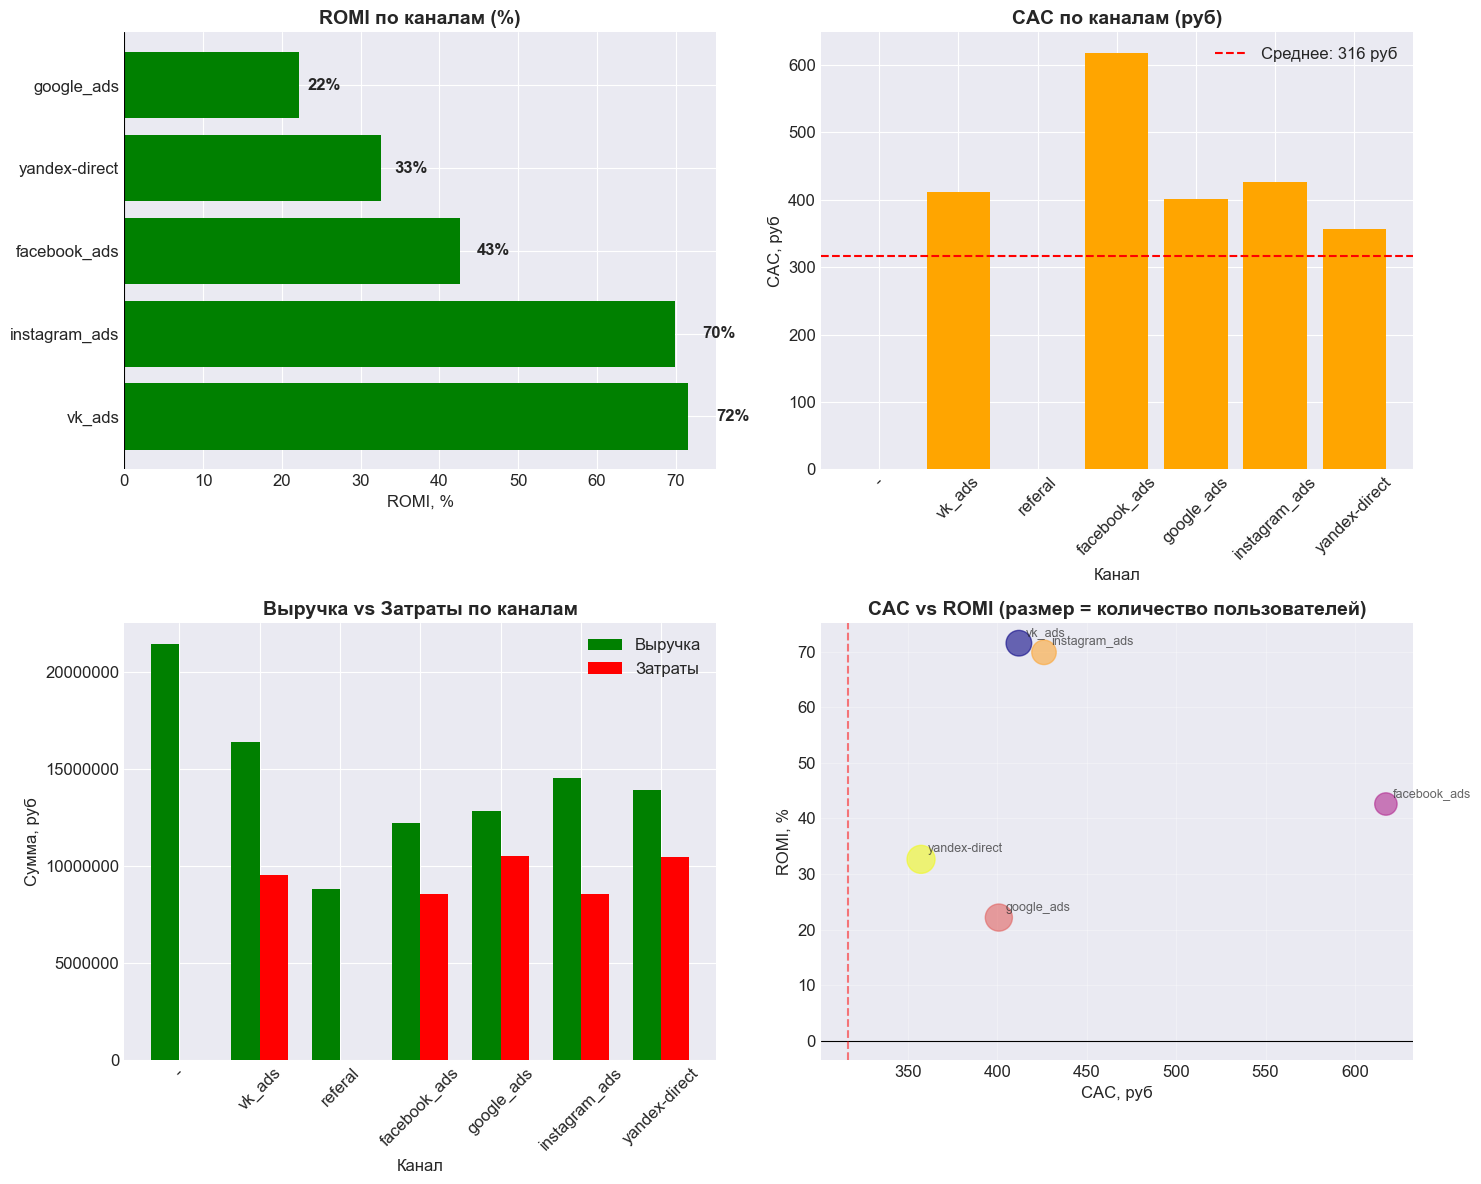


КЛЮЧЕВЫЕ ВЫВОДЫ ПО КАНАЛАМ ПРИВЛЕЧЕНИЯ
🚀 САМЫЙ ЭФФЕКТИВНЫЙ КАНАЛ: vk_ads
   • ROMI: 72%
   • Выручка: 16,389,652 руб
   • Затраты: 9,553,531 руб
   • CAC: 412 руб

⚠️ НАИМЕНЕЕ ЭФФЕКТИВНЫЙ КАНАЛ: google_ads
   • ROMI: 22%
   • Выручка: 12,868,276 руб
   • Затраты: 10,534,878 руб
   • CAC: 401 руб

📊 РЕКОМЕНДАЦИИ:
1. Увеличить инвестиции в vk_ads
2. Провести аудит эффективности google_ads
3. Оптимизировать CAC в каналах с высокой стоимостью привлечения

📈 РЕНТАБЕЛЬНОСТЬ КАНАЛОВ:
• Рентабельных каналов: 5 из 5
• Нерентабельных каналов: 0
• Средний ROMI: 48%


In [7]:
# ============================================
# 2. АНАЛИЗ КАНАЛОВ ПРИВЛЕЧЕНИЯ
# ============================================

print("="*60)
print("2. АНАЛИЗ ЭФФЕКТИВНОСТИ КАНАЛОВ ПРИВЛЕЧЕНИЯ")
print("="*60)

# 2.1. Распределение трафика по каналам
channel_distribution = df[df['event'] == 'app_install'].groupby('utm_source').size()
channel_distribution = channel_distribution.sort_values(ascending=False)

# Визуализация с matplotlib
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Круговая диаграмма
wedges, texts, autotexts = axes[0].pie(channel_distribution.values, 
                                       labels=channel_distribution.index, 
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       colors=plt.cm.Set3(np.linspace(0, 1, len(channel_distribution))))
axes[0].set_title('Распределение установок по каналам привлечения', fontsize=14, fontweight='bold')

# Столбчатая диаграмма
bars = axes[1].barh(channel_distribution.index, channel_distribution.values, color='skyblue')
axes[1].set_title('Количество установок по каналам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Количество установок', fontsize=12)
axes[1].invert_yaxis()  # Самое большое значение сверху

# Добавляем значения на столбцы
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + max(channel_distribution.values)*0.01, 
                bar.get_y() + bar.get_height()/2,
                f'{int(width):,}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nТоп-3 канала по установкам:")
for i, (channel, count) in enumerate(channel_distribution.head(3).items(), 1):
    print(f"{i}. {channel}: {count:,} установок ({count/channel_distribution.sum()*100:.1f}%)")

# 2.2. Конверсия по каналам (от установки до покупки)
print("\n" + "="*60)
print("АНАЛИЗ КОНВЕРСИИ ПО КАНАЛАМ")
print("="*60)

channel_conversion = pd.DataFrame()

for channel in df['utm_source'].unique():
    channel_data = df[df['utm_source'] == channel]
    installs = channel_data[channel_data['event'] == 'app_install']['device_id'].nunique()
    purchases = channel_data[channel_data['event'] == 'purchase']['device_id'].nunique()
    
    if installs > 0:
        conversion_rate = (purchases / installs) * 100
    else:
        conversion_rate = 0
    
    channel_conversion = pd.concat([channel_conversion, pd.DataFrame({
        'channel': [channel],
        'installs': [installs],
        'purchases': [purchases],
        'conversion_rate': [conversion_rate]
    })])

channel_conversion = channel_conversion.sort_values('conversion_rate', ascending=False)

# Визуализация конверсии
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Столбчатая диаграмма для конверсии
bars = axes[0].barh(channel_conversion['channel'], 
                   channel_conversion['conversion_rate'], 
                   color=['green' if x > channel_conversion['conversion_rate'].mean() else 'red' 
                          for x in channel_conversion['conversion_rate']])
axes[0].set_title('Конверсия в покупку по каналам (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Конверсия, %', fontsize=12)
axes[0].axvline(x=channel_conversion['conversion_rate'].mean(), color='blue', 
                linestyle='--', alpha=0.7, label=f'Среднее: {channel_conversion["conversion_rate"].mean():.1f}%')
axes[0].legend()
axes[0].invert_yaxis()

# Добавляем значения
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', ha='left', va='center')

# Точечная диаграмма: installs vs conversion
scatter = axes[1].scatter(channel_conversion['installs'], 
                         channel_conversion['conversion_rate'],
                         s=channel_conversion['purchases']*10,  # Размер по количеству покупок
                         alpha=0.6,
                         c=range(len(channel_conversion)),
                         cmap='viridis')

axes[1].set_title('Установки vs Конверсия', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Количество установок', fontsize=12)
axes[1].set_ylabel('Конверсия, %', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Добавляем подписи точек
for i, row in channel_conversion.iterrows():
    axes[1].annotate(row['channel'], 
                    (row['installs'], row['conversion_rate']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9)

# Цветовая легенда для размера точек
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor='gray', markersize=10, label='Маленький объем'),
                   Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor='gray', markersize=20, label='Средний объем'),
                   Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor='gray', markersize=30, label='Большой объем')]
axes[1].legend(handles=legend_elements, title="Объем покупок")

plt.tight_layout()
plt.show()

# 2.3. CAC и ROMI по каналам
print("\n" + "="*60)
print("АНАЛИЗ ЭФФЕКТИВНОСТИ КАНАЛОВ (CAC & ROMI)")
print("="*60)

# Предположим затраты на рекламу (данные из задания)
channel_costs = {
    'yandex-direct': 10491707,
    'google_ads': 10534878,
    'facebook_ads': 8590498,
    'instagram_ads': 8561626,
    'vk_ads': 9553531,
    'referral': 1160600,
    '-': 0
}

# Рассчитываем метрики для каждого канала
channel_metrics = []

for channel in df['utm_source'].unique():
    channel_data = df[df['utm_source'] == channel]
    
    # Базовые метрики
    users = channel_data['device_id'].nunique()
    installs = channel_data[channel_data['event'] == 'app_install']['device_id'].nunique()
    purchases = channel_data[channel_data['event'] == 'purchase']['device_id'].nunique()
    revenue = channel_data[channel_data['event'] == 'purchase']['purchase_sum'].sum()
    
    # Расходы
    cost = channel_costs.get(channel, 0)
    
    # Расчет метрик
    cac = cost / installs if installs > 0 else 0
    arpu = revenue / users if users > 0 else 0
    romi = ((revenue - cost) / cost) * 100 if cost > 0 else np.inf
    
    # AOV (Average Order Value)
    aov = revenue / purchases if purchases > 0 else 0
    
    channel_metrics.append({
        'Канал': channel,
        'Пользователи': users,
        'Установки': installs,
        'Покупки': purchases,
        'Выручка': revenue,
        'Затраты': cost,
        'CAC': cac,
        'ARPU': arpu,
        'ROMI': romi,
        'AOV': aov
    })

channel_metrics_df = pd.DataFrame(channel_metrics)

print("\nСводная таблица эффективности каналов:")
display(channel_metrics_df.sort_values('ROMI', ascending=False))

# Визуализация ROMI
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROMI по каналам
channel_metrics_sorted = channel_metrics_df[channel_metrics_df['ROMI'] < np.inf].sort_values('ROMI')
bars1 = axes[0, 0].barh(channel_metrics_sorted['Канал'], channel_metrics_sorted['ROMI'],
                       color=['green' if x > 0 else 'red' for x in channel_metrics_sorted['ROMI']])
axes[0, 0].set_title('ROMI по каналам (%)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('ROMI, %', fontsize=12)
axes[0, 0].axvline(x=0, color='black', linewidth=0.8)
axes[0, 0].invert_yaxis()

# Добавляем значения ROMI
for bar in bars1:
    width = bar.get_width()
    axes[0, 0].text(width + (abs(width)*0.05 if width >= 0 else -abs(width)*0.05), 
                   bar.get_y() + bar.get_height()/2,
                   f'{width:.0f}%', ha='left' if width >= 0 else 'right', va='center',
                   fontweight='bold')

# 2. CAC по каналам
bars2 = axes[0, 1].bar(channel_metrics_df['Канал'], channel_metrics_df['CAC'], color='orange')
axes[0, 1].set_title('CAC по каналам (руб)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Канал', fontsize=12)
axes[0, 1].set_ylabel('CAC, руб', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=channel_metrics_df['CAC'].mean(), color='red', linestyle='--', 
                   label=f'Среднее: {channel_metrics_df["CAC"].mean():,.0f} руб')
axes[0, 1].legend()

# 3. Соотношение выручки и затрат
x = np.arange(len(channel_metrics_df))
width = 0.35
bars3a = axes[1, 0].bar(x - width/2, channel_metrics_df['Выручка'], width, label='Выручка', color='green')
bars3b = axes[1, 0].bar(x + width/2, channel_metrics_df['Затраты'], width, label='Затраты', color='red')
axes[1, 0].set_title('Выручка vs Затраты по каналам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Канал', fontsize=12)
axes[1, 0].set_ylabel('Сумма, руб', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(channel_metrics_df['Канал'], rotation=45)
axes[1, 0].legend()
axes[1, 0].ticklabel_format(style='plain', axis='y')

# 4. Пузырьковая диаграмма: CAC vs ROMI vs Объем
scatter = axes[1, 1].scatter(channel_metrics_df['CAC'], 
                            channel_metrics_df['ROMI'].replace([np.inf, -np.inf], np.nan),
                            s=channel_metrics_df['Пользователи']/100,
                            alpha=0.6,
                            c=range(len(channel_metrics_df)),
                            cmap='plasma')

axes[1, 1].set_title('CAC vs ROMI (размер = количество пользователей)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('CAC, руб', fontsize=12)
axes[1, 1].set_ylabel('ROMI, %', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linewidth=0.8)
axes[1, 1].axvline(x=channel_metrics_df['CAC'].mean(), color='red', linestyle='--', alpha=0.5)

# Добавляем подписи каналов
for i, row in channel_metrics_df.iterrows():
    romi_value = row['ROMI'] if row['ROMI'] != np.inf else 1000  # Заменяем inf на большое число
    axes[1, 1].annotate(row['Канал'], 
                       (row['CAC'], romi_value),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Выводы по анализу каналов
print("\n" + "="*60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ ПО КАНАЛАМ ПРИВЛЕЧЕНИЯ")
print("="*60)

# Находим лучший и худший каналы по ROMI (исключая бесконечные значения)
valid_romi = channel_metrics_df[channel_metrics_df['ROMI'] < np.inf].copy()
if not valid_romi.empty:
    best_channel = valid_romi.loc[valid_romi['ROMI'].idxmax()]
    worst_channel = valid_romi.loc[valid_romi['ROMI'].idxmin()]
    
    print(f"🚀 САМЫЙ ЭФФЕКТИВНЫЙ КАНАЛ: {best_channel['Канал']}")
    print(f"   • ROMI: {best_channel['ROMI']:.0f}%")
    print(f"   • Выручка: {best_channel['Выручка']:,.0f} руб")
    print(f"   • Затраты: {best_channel['Затраты']:,.0f} руб")
    print(f"   • CAC: {best_channel['CAC']:,.0f} руб")
    
    print(f"\n⚠️ НАИМЕНЕЕ ЭФФЕКТИВНЫЙ КАНАЛ: {worst_channel['Канал']}")
    print(f"   • ROMI: {worst_channel['ROMI']:.0f}%")
    print(f"   • Выручка: {worst_channel['Выручка']:,.0f} руб")
    print(f"   • Затраты: {worst_channel['Затраты']:,.0f} руб")
    print(f"   • CAC: {worst_channel['CAC']:,.0f} руб")
    
    # Рекомендации
    print(f"\n📊 РЕКОМЕНДАЦИИ:")
    print(f"1. Увеличить инвестиции в {best_channel['Канал']}")
    print(f"2. Провести аудит эффективности {worst_channel['Канал']}")
    print(f"3. Оптимизировать CAC в каналах с высокой стоимостью привлечения")
    
    # Анализ рентабельности
    profitable_channels = valid_romi[valid_romi['ROMI'] > 0]
    unprofitable_channels = valid_romi[valid_romi['ROMI'] <= 0]
    
    print(f"\n📈 РЕНТАБЕЛЬНОСТЬ КАНАЛОВ:")
    print(f"• Рентабельных каналов: {len(profitable_channels)} из {len(valid_romi)}")
    print(f"• Нерентабельных каналов: {len(unprofitable_channels)}")
    print(f"• Средний ROMI: {valid_romi['ROMI'].mean():.0f}%")

3. АНАЛИЗ ВОРОНКИ ПРОДАЖ И ПОВЕДЕНИЯ ПОЛЬЗОВАТЕЛЕЙ

Воронка продаж:
         event   users  conversion_from_previous  conversion_from_start
0    app_start  190884                       NaN             100.000000
1       search  184488                 96.649274              96.649274
2  choose_item  155691                 84.390855              81.563148
3   tap_basket  125414                 80.553147              65.701683
4     purchase   70875                 56.512830              37.129880


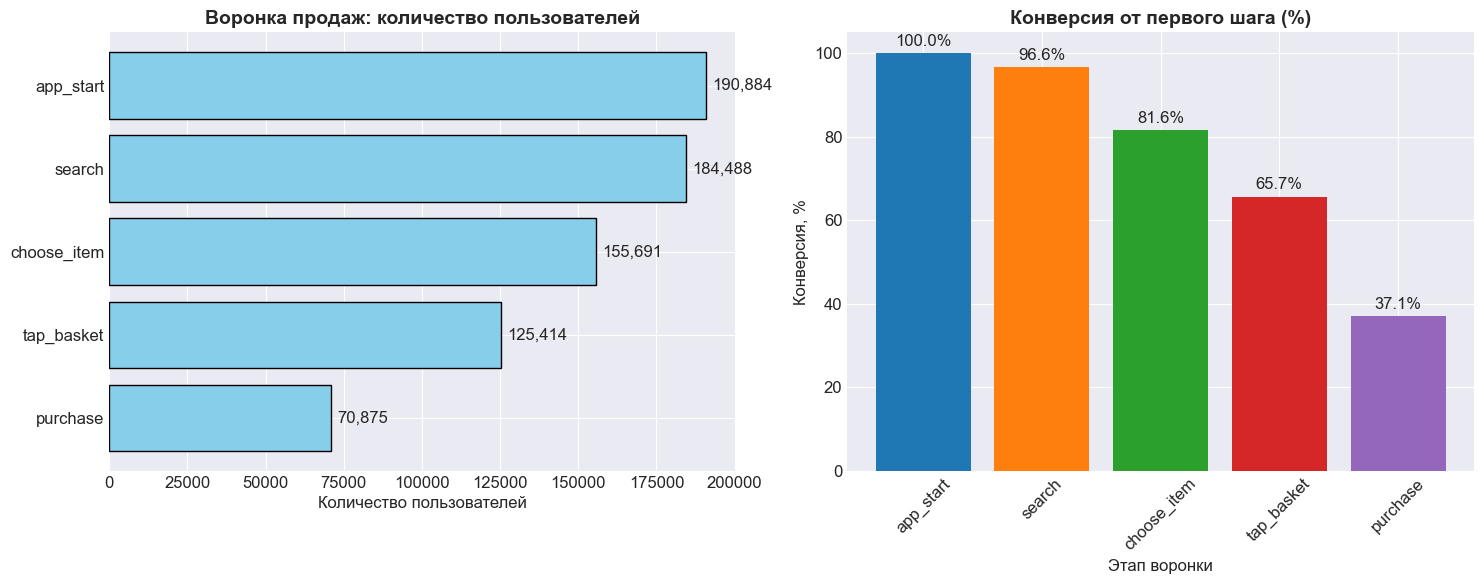


Анализ оттока на каждом этапе:
       Этап  Осталось пользователей  Выбыло на этапе  Процент оттока
     search                  184488           6396.0        3.350726
choose_item                  155691          28797.0       15.609145
 tap_basket                  125414          30277.0       19.446853
   purchase                   70875          54539.0       43.487170


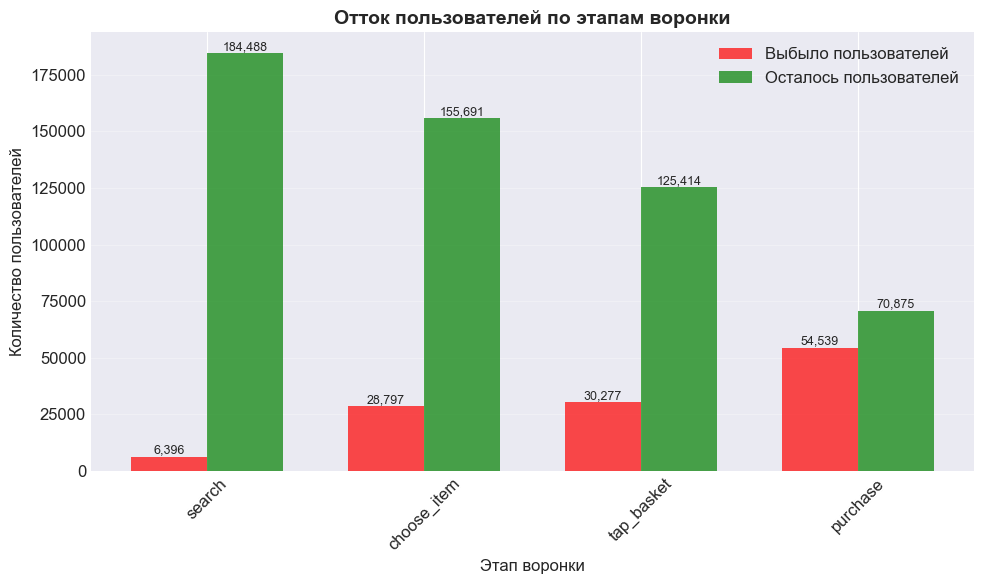

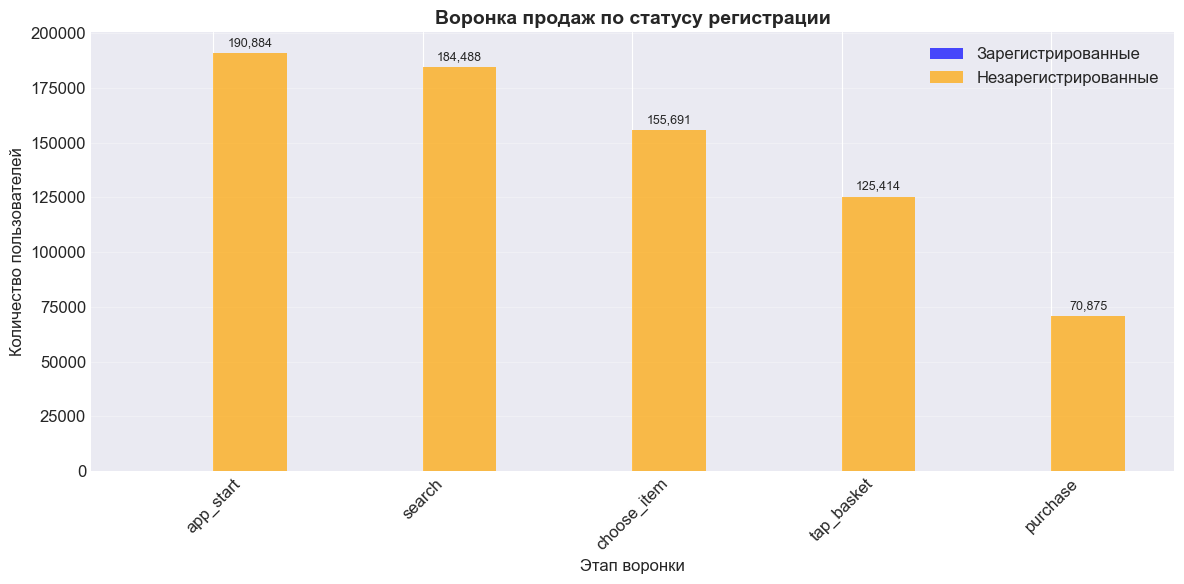


Среднее время между событиями (часы):
app_start → search: 48.0 часов (выборка: 24 пользователей)
search → choose_item: 48.0 часов (выборка: 101 пользователей)
choose_item → tap_basket: 48.0 часов (выборка: 115 пользователей)
tap_basket → purchase: 72.0 часов (выборка: 129 пользователей)


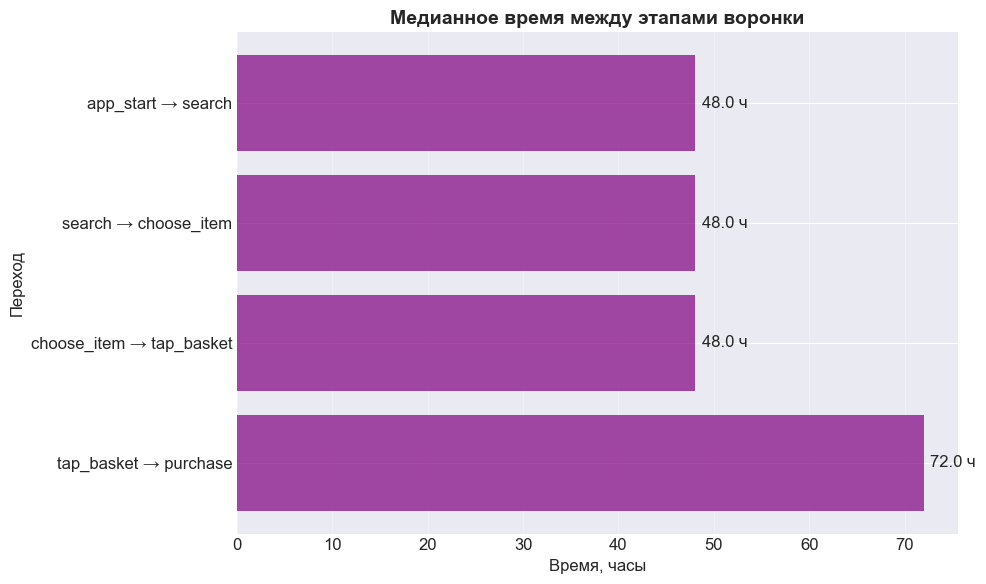


ДЕТАЛЬНЫЙ АНАЛИЗ КОНВЕРСИИ

Конверсия между последовательными этапами:
    От шага      К шагу  Совершили первый шаг  Совершили оба шага Конверсия  Потеряно пользователей
  app_start      search                190884              184488     96.6%                    6396
     search choose_item                184488              155691     84.4%                   28797
choose_item  tap_basket                155691              125414     80.6%                   30277
 tap_basket    purchase                125414               70875     56.5%                   54539


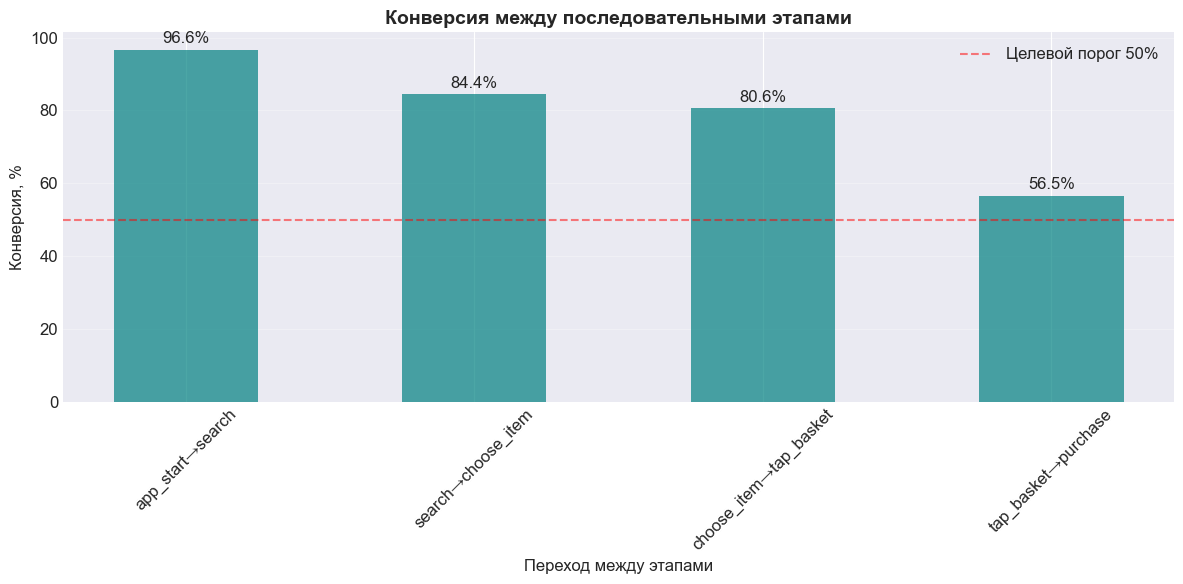

In [9]:
# ============================================
# 3. ВОРОНКА ПРОДАЖ И ПОВЕДЕНЧЕСКИЙ АНАЛИЗ
# ============================================

print("="*60)
print("3. АНАЛИЗ ВОРОНКИ ПРОДАЖ И ПОВЕДЕНИЯ ПОЛЬЗОВАТЕЛЕЙ")
print("="*60)

# 3.1. Определяем порядок событий в воронке
event_sequence = ['app_start', 'search', 'choose_item', 'tap_basket', 'purchase']

# Создаем воронку для всех пользователей
funnel_data = []

for event in event_sequence:
    users_count = df[df['event'] == event]['device_id'].nunique()
    funnel_data.append({
        'event': event,
        'users': users_count
    })

funnel_df = pd.DataFrame(funnel_data)
funnel_df['conversion_from_previous'] = (funnel_df['users'] / funnel_df['users'].shift(1)) * 100
funnel_df['conversion_from_start'] = (funnel_df['users'] / funnel_df['users'].iloc[0]) * 100

print("\nВоронка продаж:")
print(funnel_df.to_string())

# 3.2. Визуализация воронки с matplotlib
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Левая часть: воронка (ступенчатая диаграмма)
# Для визуализации воронки создаем "ступеньки"
funnel_steps = []
for i, (event, count) in enumerate(zip(funnel_df['event'], funnel_df['users'])):
    if i == 0:
        funnel_steps.append(count)
    else:
        funnel_steps.append(count)
    
axes[0].barh(range(len(funnel_steps)), funnel_steps, color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(funnel_steps)))
axes[0].set_yticklabels(funnel_df['event'])
axes[0].invert_yaxis()
axes[0].set_title('Воронка продаж: количество пользователей', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество пользователей', fontsize=12)

# Добавляем значения на столбцы
for i, v in enumerate(funnel_steps):
    axes[0].text(v + max(funnel_steps)*0.01, i, f'{v:,}', va='center')

# Правая часть: конверсия от старта
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = axes[1].bar(funnel_df['event'], funnel_df['conversion_from_start'], color=colors)
axes[1].set_title('Конверсия от первого шага (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Этап воронки', fontsize=12)
axes[1].set_ylabel('Конверсия, %', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, value in zip(bars, funnel_df['conversion_from_start']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 3.3. Анализ оттока на каждом этапе
dropoff_analysis = pd.DataFrame({
    'Этап': event_sequence,
    'Осталось пользователей': funnel_df['users'],
    'Выбыло на этапе': funnel_df['users'].shift(1) - funnel_df['users'],
    'Процент оттока': ((funnel_df['users'].shift(1) - funnel_df['users']) / funnel_df['users'].shift(1)) * 100
})

print("\nАнализ оттока на каждом этапе:")
print(dropoff_analysis.dropna().to_string(index=False))

# Визуализация оттока
fig, ax = plt.subplots(figsize=(10, 6))

# Создаем два графика на одной оси
x = np.arange(len(dropoff_analysis.dropna()))
width = 0.35

bars1 = ax.bar(x - width/2, dropoff_analysis.dropna()['Выбыло на этапе'], 
               width, label='Выбыло пользователей', color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, dropoff_analysis.dropna()['Осталось пользователей'], 
               width, label='Осталось пользователей', color='green', alpha=0.7)

ax.set_title('Отток пользователей по этапам воронки', fontsize=14, fontweight='bold')
ax.set_xlabel('Этап воронки', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(dropoff_analysis.dropna()['Этап'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Только для положительных значений
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3.4. Воронка для зарегистрированных vs незарегистрированных пользователей
df['is_registered'] = df['event'] == 'registration'
df['registration_status'] = df.groupby('device_id')['is_registered'].transform('max')
df['registration_status'] = df['registration_status'].map({True: 'Registered', False: 'Not Registered'})

# Анализ по группам
funnel_by_reg = pd.DataFrame()

for status in ['Registered', 'Not Registered']:
    temp_data = []
    group_df = df[df['registration_status'] == status]
    
    for event in event_sequence:
        users_count = group_df[group_df['event'] == event]['device_id'].nunique()
        temp_data.append({
            'registration_status': status,
            'event': event,
            'users': users_count
        })
    
    funnel_by_reg = pd.concat([funnel_by_reg, pd.DataFrame(temp_data)])

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

# Преобразуем данные для построения графика
registered_data = funnel_by_reg[funnel_by_reg['registration_status'] == 'Registered']
not_registered_data = funnel_by_reg[funnel_by_reg['registration_status'] == 'Not Registered']

x = np.arange(len(event_sequence))
width = 0.35

ax.bar(x - width/2, registered_data['users'], width, label='Зарегистрированные', color='blue', alpha=0.7)
ax.bar(x + width/2, not_registered_data['users'], width, label='Незарегистрированные', color='orange', alpha=0.7)

ax.set_title('Воронка продаж по статусу регистрации', fontsize=14, fontweight='bold')
ax.set_xlabel('Этап воронки', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(event_sequence, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (reg_val, not_reg_val) in enumerate(zip(registered_data['users'], not_registered_data['users'])):
    if reg_val > 0:
        ax.text(i - width/2, reg_val + max(max(registered_data['users']), max(not_registered_data['users'])) * 0.01,
               f'{reg_val:,}', ha='center', va='bottom', fontsize=9)
    if not_reg_val > 0:
        ax.text(i + width/2, not_reg_val + max(max(registered_data['users']), max(not_registered_data['users'])) * 0.01,
               f'{not_reg_val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3.5. Время между этапами воронки
print("\nСреднее время между событиями (часы):")
time_analysis = []

for i in range(len(event_sequence)-1):
    event1 = event_sequence[i]
    event2 = event_sequence[i+1]
    
    # Для каждого пользователя находим время между событиями
    times_between = []
    
    # Ограничиваем выборку для скорости
    sample_users = df['device_id'].unique()[:1000]
    
    for user in sample_users:
        user_events = df[df['device_id'] == user].sort_values('date')
        event1_time = user_events[user_events['event'] == event1]['date']
        event2_time = user_events[user_events['event'] == event2]['date']
        
        if not event1_time.empty and not event2_time.empty:
            time_diff = (event2_time.iloc[0] - event1_time.iloc[0]).total_seconds() / 3600
            if 0 < time_diff < 168:  # Ограничиваем неделей
                times_between.append(time_diff)
    
    if times_between:
        avg_time = np.median(times_between)
        time_analysis.append({
            'transition': f'{event1} → {event2}',
            'median_time_hours': avg_time,
            'sample_size': len(times_between)
        })
        print(f"{event1} → {event2}: {avg_time:.1f} часов (выборка: {len(times_between)} пользователей)")

# Визуализация времени между событиями
if time_analysis:
    time_df = pd.DataFrame(time_analysis)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(time_df['transition'], time_df['median_time_hours'], color='purple', alpha=0.7)
    ax.set_title('Медианное время между этапами воронки', fontsize=14, fontweight='bold')
    ax.set_xlabel('Время, часы', fontsize=12)
    ax.set_ylabel('Переход', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max(time_df['median_time_hours'])*0.01, 
               bar.get_y() + bar.get_height()/2,
               f'{width:.1f} ч', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()

# 3.6. Детальный анализ конверсии между этапами
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КОНВЕРСИИ")
print("="*60)

conversion_details = []

for i in range(len(event_sequence)-1):
    from_event = event_sequence[i]
    to_event = event_sequence[i+1]
    
    # Пользователи, которые совершили первый шаг
    users_from = df[df['event'] == from_event]['device_id'].unique()
    
    # Пользователи, которые совершили следующий шаг
    users_to = df[df['event'] == to_event]['device_id'].unique()
    
    # Пользователи, которые совершили оба шага
    users_both = set(users_from) & set(users_to)
    
    conversion_rate = (len(users_both) / len(users_from)) * 100 if len(users_from) > 0 else 0
    
    conversion_details.append({
        'От шага': from_event,
        'К шагу': to_event,
        'Совершили первый шаг': len(users_from),
        'Совершили оба шага': len(users_both),
        'Конверсия': f'{conversion_rate:.1f}%',
        'Потеряно пользователей': len(users_from) - len(users_both)
    })

conversion_details_df = pd.DataFrame(conversion_details)
print("\nКонверсия между последовательными этапами:")
print(conversion_details_df.to_string(index=False))

# Визуализация конверсии между этапами
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(conversion_details_df))
width = 0.5

bars = ax.bar(x, [float(cd['Конверсия'][:-1]) for cd in conversion_details], 
              width, color='teal', alpha=0.7)

ax.set_title('Конверсия между последовательными этапами', fontsize=14, fontweight='bold')
ax.set_xlabel('Переход между этапами', fontsize=12)
ax.set_ylabel('Конверсия, %', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{cd['От шага']}→{cd['К шагу']}" for cd in conversion_details], rotation=45)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Целевой порог 50%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, detail in zip(bars, conversion_details):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
           f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

4. КОГОРТНЫЙ АНАЛИЗ

4.2. Когортный анализ по установкам:


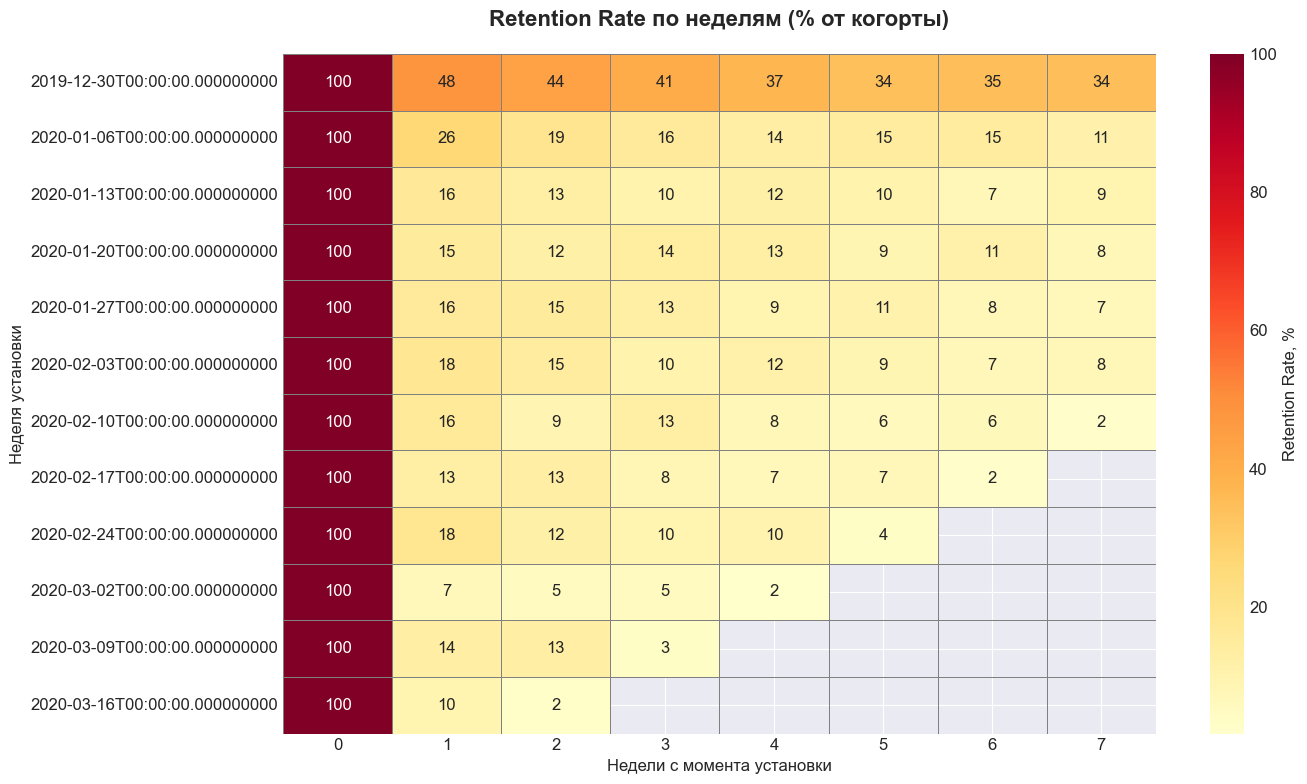

Лучшая когорта по retention (неделя 1): 30.12.2019
Retention Week 1: 48.4%

4.3. АНАЛИЗ LTV (LIFETIME VALUE) ПО КОГОРТАМ


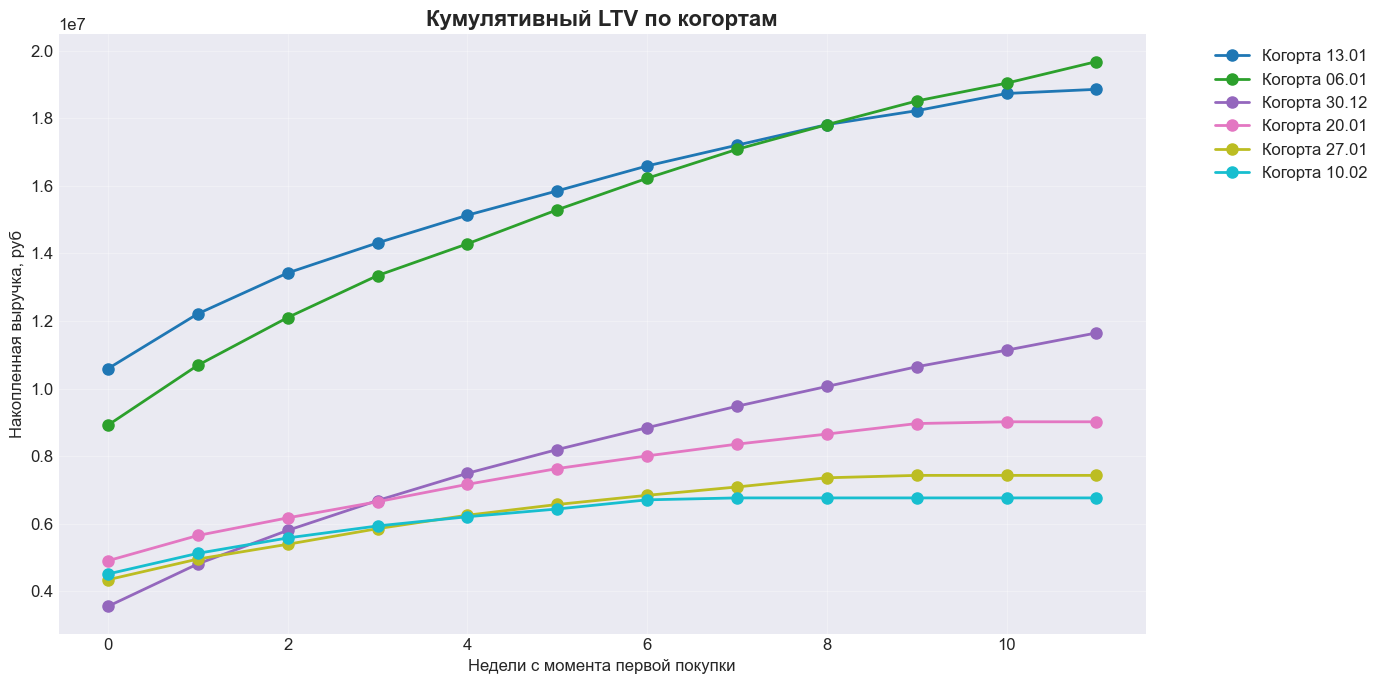


Когорта с максимальным LTV (к 4-й неделе):
Дата когорты: 13.01.2020
LTV за 4 недель: 15,129,588 руб

Сравнение топ-3 когорт по LTV:
1. 13.01.2020: 188,911,928 руб
2. 06.01.2020: 182,949,992 руб
3. 30.12.2019: 98,376,162 руб

4.4. АНАЛИЗ ПАЙПЛАЙНА КОГОРТ

Анализ пайплайна когорт (первые 6 когорт):
--------------------------------------------------

Когорта 30.12.2019:
  Всего пользователей: 12,627
  Retention Week 1: 6,117 (48.4%)
  Retention Week 4: 4,693 (37.2%)

Когорта 06.01.2020:
  Всего пользователей: 25,432
  Retention Week 1: 6,682 (26.3%)
  Retention Week 4: 3,445 (13.5%)
  Рост когорты: +101.4%

Когорта 13.01.2020:
  Всего пользователей: 24,658
  Retention Week 1: 4,065 (16.5%)
  Retention Week 4: 2,926 (11.9%)
  Рост когорты: -3.0%

Когорта 20.01.2020:
  Всего пользователей: 10,088
  Retention Week 1: 1,542 (15.3%)
  Retention Week 4: 1,288 (12.8%)
  Рост когорты: -59.1%

Когорта 27.01.2020:
  Всего пользователей: 10,569
  Retention Week 1: 1,658 (15.7%)
  Retention Week 4: 

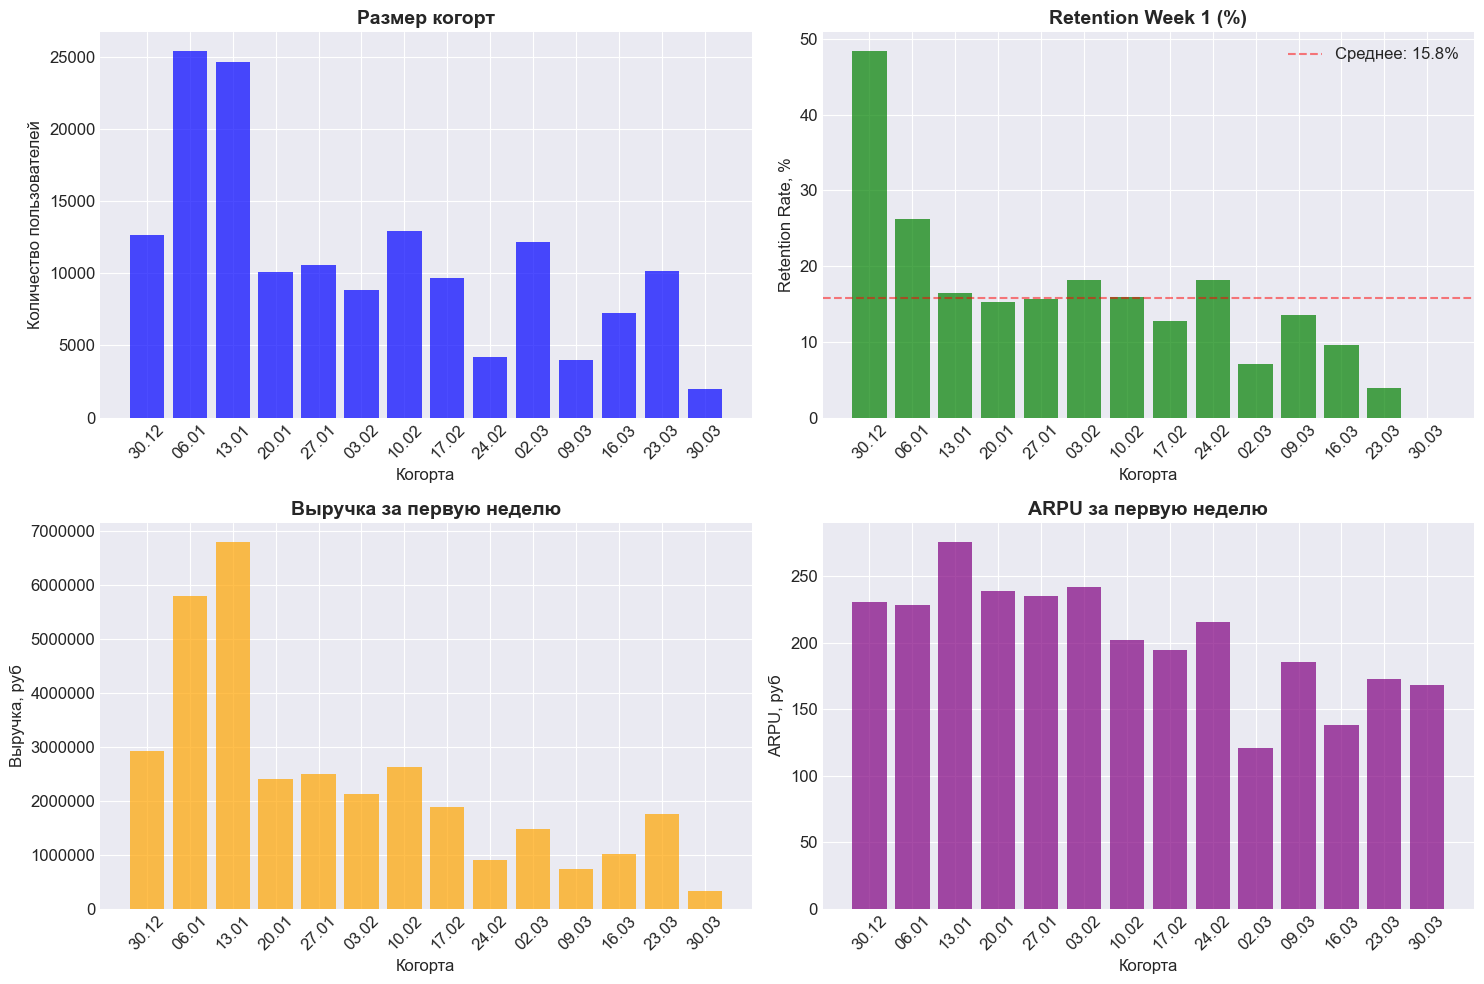


Ключевые выводы по сравнительному анализу когорт:
--------------------------------------------------
Лучшая когорта по Retention: 30.12.2019
  • Retention Week 1: 48.4%
  • Размер когорты: 12,627
  • ARPU Week 1: 231 руб

Худшая когорта по Retention: 30.03.2020
  • Retention Week 1: 0.0%
  • Размер когорты: 1,962
  • ARPU Week 1: 168 руб

Средние показатели по всем когортам:
  • Средний Retention Week 1: 15.8%
  • Средний размер когорты: 11043
  • Средний ARPU Week 1: 203 руб


In [11]:
# ============================================
# 4. КОГОРТНЫЙ АНАЛИЗ
# ============================================

print("="*60)
print("4. КОГОРТНЫЙ АНАЛИЗ")
print("="*60)

# 4.1. Создаем функцию для когортного анализа с исправлениями
def create_cohort_analysis(df, cohort_type='install', weeks_to_analyze=8):
    """
    Создает когортный анализ для разных типов когорт
    """
    df_copy = df.copy()
    
    if cohort_type == 'install':
        # Когорты по неделе установки
        install_dates = df_copy[df_copy['event'] == 'app_install'].groupby('device_id')['date'].min()
        df_copy['cohort_date'] = df_copy['device_id'].map(install_dates)
    elif cohort_type == 'registration':
        # Когорты по неделе регистрации
        reg_dates = df_copy[df_copy['event'] == 'registration'].groupby('device_id')['date'].min()
        df_copy['cohort_date'] = df_copy['device_id'].map(reg_dates)
    elif cohort_type == 'first_purchase':
        # Когорты по неделе первой покупки
        purchase_dates = df_copy[df_copy['event'] == 'purchase'].groupby('device_id')['date'].min()
        df_copy['cohort_date'] = df_copy['device_id'].map(purchase_dates)
    
    # Убираем пользователей без когорты
    df_copy = df_copy.dropna(subset=['cohort_date'])
    
    # Создаем когорты по неделям (начало недели)
    df_copy['cohort_week'] = df_copy['cohort_date'].dt.to_period('W').dt.start_time
    
    # Рассчитываем недели с момента когорты
    df_copy['weeks_since'] = ((df_copy['date'] - df_copy['cohort_week']).dt.days // 7)
    
    # Ограничиваем количество недель для анализа
    df_copy = df_copy[df_copy['weeks_since'] >= 0]
    df_copy = df_copy[df_copy['weeks_since'] < weeks_to_analyze]
    
    # Создаем когортную таблицу (Retention)
    # Для анализа retention используем событие app_start
    retention_df = df_copy[df_copy['event'] == 'app_start'].copy()
    
    cohort_pivot = retention_df.pivot_table(
        index='cohort_week',
        columns='weeks_since',
        values='device_id',
        aggfunc=pd.Series.nunique,
        fill_value=0
    )
    
    # Если нет данных для некоторых недель, добавляем нулевые столбцы
    for week in range(weeks_to_analyze):
        if week not in cohort_pivot.columns:
            cohort_pivot[week] = 0
    
    # Сортируем столбцы по порядку
    cohort_pivot = cohort_pivot.reindex(sorted(cohort_pivot.columns), axis=1)
    
    # Нормализуем для Retention Rate
    if not cohort_pivot.empty:
        cohort_size = cohort_pivot.iloc[:, 0]
        retention_rate = cohort_pivot.divide(cohort_size, axis=0) * 100
        retention_rate = retention_rate.replace([np.inf, -np.inf], np.nan)
    else:
        retention_rate = pd.DataFrame()
    
    return cohort_pivot, retention_rate

# 4.2. Когортный анализ по установкам
print("\n4.2. Когортный анализ по установкам:")
cohort_counts, cohort_retention = create_cohort_analysis(df, 'install', weeks_to_analyze=12)

if not cohort_counts.empty:
    # Визуализация Retention Heatmap
    plt.figure(figsize=(14, 8))
    
    # Ограничиваем для отображения
    display_retention = cohort_retention.copy()
    if len(display_retention) > 12:
        display_retention = display_retention.head(12)
    if len(display_retention.columns) > 8:
        display_retention = display_retention.iloc[:, :8]
    
    # Создаем маску для скрытия нулевых значений
    mask = display_retention == 0
    
    sns.heatmap(display_retention, 
                annot=True, 
                fmt='.0f', 
                cmap='YlOrRd',
                linewidths=0.5, 
                linecolor='gray',
                mask=mask,
                cbar_kws={'label': 'Retention Rate, %'})
    
    plt.title('Retention Rate по неделям (% от когорты)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Недели с момента установки', fontsize=12)
    plt.ylabel('Неделя установки', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Анализ лучшей когорты
    if not cohort_counts.empty:
        # Находим самую активную когорту (по максимальному retention на неделе 1)
        if 1 in cohort_retention.columns:
            best_cohort_idx = cohort_retention[1].idxmax()
            best_cohort_retention = cohort_retention.loc[best_cohort_idx, 1]
            print(f"Лучшая когорта по retention (неделя 1): {best_cohort_idx.strftime('%d.%m.%Y')}")
            print(f"Retention Week 1: {best_cohort_retention:.1f}%")
else:
    print("Недостаточно данных для когортного анализа по установкам")

# 4.3. Анализ LTV (Lifetime Value) когорт
print("\n" + "="*60)
print("4.3. АНАЛИЗ LTV (LIFETIME VALUE) ПО КОГОРТАМ")
print("="*60)

# Создаем когорты для LTV анализа
cohort_revenue = df[df['event'] == 'purchase'].copy()

if not cohort_revenue.empty:
    # Находим дату первой покупки для каждого пользователя
    first_purchase_dates = cohort_revenue.groupby('device_id')['date'].min()
    cohort_revenue['first_purchase_date'] = cohort_revenue['device_id'].map(first_purchase_dates)
    
    # Создаем когорты по неделям первой покупки
    cohort_revenue['cohort_week'] = cohort_revenue['first_purchase_date'].dt.to_period('W').dt.start_time
    
    # Рассчитываем недели с момента первой покупки
    cohort_revenue['weeks_since_purchase'] = ((cohort_revenue['date'] - cohort_revenue['cohort_week']).dt.days // 7)
    
    # Ограничиваем анализ 12 неделями
    cohort_revenue = cohort_revenue[cohort_revenue['weeks_since_purchase'] < 12]
    
    # LTV по неделям
    ltv_by_week = cohort_revenue.pivot_table(
        index='cohort_week',
        columns='weeks_since_purchase',
        values='purchase_sum',
        aggfunc='sum',
        fill_value=0
    )
    
    # Кумулятивный LTV
    cumulative_ltv = ltv_by_week.cumsum(axis=1)
    
    # Визуализация LTV
    plt.figure(figsize=(14, 7))
    
    # Выбираем топ-6 когорт для отображения
    top_cohorts = cumulative_ltv.sum(axis=1).nlargest(6).index
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_cohorts)))
    
    for i, cohort_date in enumerate(top_cohorts):
        plt.plot(cumulative_ltv.columns, 
                cumulative_ltv.loc[cohort_date].values, 
                marker='o', 
                linewidth=2,
                markersize=8,
                label=f"Когорта {cohort_date.strftime('%d.%m')}",
                color=colors[i])
    
    plt.title('Кумулятивный LTV по когортам', fontsize=16, fontweight='bold')
    plt.xlabel('Недели с момента первой покупки', fontsize=12)
    plt.ylabel('Накопленная выручка, руб', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Анализ лучшей когорты по LTV
    if not cumulative_ltv.empty:
        # Находим когорту с максимальным LTV на 4-й неделе
        week_to_analyze = 4 if 4 in cumulative_ltv.columns else cumulative_ltv.columns[-1]
        best_ltv_cohort = cumulative_ltv[week_to_analyze].idxmax()
        best_ltv_value = cumulative_ltv.loc[best_ltv_cohort, week_to_analyze]
        
        print(f"\nКогорта с максимальным LTV (к {week_to_analyze}-й неделе):")
        print(f"Дата когорты: {best_ltv_cohort.strftime('%d.%m.%Y')}")
        print(f"LTV за {week_to_analyze} недель: {best_ltv_value:,.0f} руб")
        
        # Сравнение когорт
        print("\nСравнение топ-3 когорт по LTV:")
        top_3_ltv = cumulative_ltv.sum(axis=1).nlargest(3)
        for i, (cohort_date, total_ltv) in enumerate(top_3_ltv.items(), 1):
            print(f"{i}. {cohort_date.strftime('%d.%m.%Y')}: {total_ltv:,.0f} руб")
else:
    print("Недостаточно данных для анализа LTV")

# 4.4. Анализ пайплайна когорт
print("\n" + "="*60)
print("4.4. АНАЛИЗ ПАЙПЛАЙНА КОГОРТ")
print("="*60)

# Анализ когорт по установкам
if not cohort_counts.empty and len(cohort_counts.columns) >= 5:
    print("\nАнализ пайплайна когорт (первые 6 когорт):")
    print("-"*50)
    
    for i, week in enumerate(cohort_counts.index[:6]):
        cohort_users = cohort_counts.iloc[i, 0] if 0 in cohort_counts.columns else 0
        
        # Проверяем наличие столбцов
        retained_week1 = cohort_counts.iloc[i, 1] if 1 in cohort_counts.columns else 0
        retained_week4 = cohort_counts.iloc[i, 4] if 4 in cohort_counts.columns else 0
        
        if cohort_users > 0:
            retention_week1_pct = (retained_week1 / cohort_users) * 100
            retention_week4_pct = (retained_week4 / cohort_users) * 100 if retained_week4 > 0 else 0
            
            print(f"\nКогорта {week.strftime('%d.%m.%Y')}:")
            print(f"  Всего пользователей: {cohort_users:,}")
            print(f"  Retention Week 1: {retained_week1:,} ({retention_week1_pct:.1f}%)")
            print(f"  Retention Week 4: {retained_week4:,} ({retention_week4_pct:.1f}%)")
            
            # Анализ тренда
            if i > 0:
                prev_cohort_users = cohort_counts.iloc[i-1, 0] if 0 in cohort_counts.columns else 0
                if prev_cohort_users > 0:
                    growth = ((cohort_users - prev_cohort_users) / prev_cohort_users) * 100
                    print(f"  Рост когорты: {growth:+.1f}%")
else:
    print("Недостаточно данных для анализа пайплайна когорт")

# 4.5. Анализ когорт по регистрации
print("\n" + "="*60)
print("4.5. КОГОРТНЫЙ АНАЛИЗ ПО РЕГИСТРАЦИИ")
print("="*60)

reg_cohort_counts, reg_cohort_retention = create_cohort_analysis(df, 'registration', weeks_to_analyze=8)

if not reg_cohort_counts.empty:
    # Визуализация
    plt.figure(figsize=(12, 6))
    
    # Ограничиваем для отображения
    display_reg_retention = reg_cohort_retention.copy()
    if len(display_reg_retention) > 8:
        display_reg_retention = display_reg_retention.head(8)
    if len(display_reg_retention.columns) > 6:
        display_reg_retention = display_reg_retention.iloc[:, :6]
    
    mask = display_reg_retention == 0
    
    sns.heatmap(display_reg_retention, 
                annot=True, 
                fmt='.0f', 
                cmap='Blues',
                linewidths=0.5, 
                linecolor='gray',
                mask=mask,
                cbar_kws={'label': 'Retention Rate, %'})
    
    plt.title('Retention Rate по неделям после регистрации', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Недели с момента регистрации', fontsize=12)
    plt.ylabel('Неделя регистрации', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Анализ
    print("\nАнализ когорт по регистрации:")
    print("-"*40)
    
    if 1 in reg_cohort_retention.columns:
        best_reg_cohort = reg_cohort_retention[1].idxmax()
        best_reg_retention = reg_cohort_retention.loc[best_reg_cohort, 1]
        print(f"Лучшая когорта по retention после регистрации: {best_reg_cohort.strftime('%d.%m.%Y')}")
        print(f"Retention Week 1: {best_reg_retention:.1f}%")
        
        # Средний retention
        avg_retention = reg_cohort_retention[1].mean()
        print(f"Средний Retention Week 1: {avg_retention:.1f}%")
else:
    print("Недостаточно данных для когортного анализа по регистрации")

# 4.6. Сравнительный анализ когорт
print("\n" + "="*60)
print("4.6. СРАВНИТЕЛЬНЫЙ АНАЛИЗ КОГОРТ")
print("="*60)

# Собираем данные для сравнения
comparison_data = []

if not cohort_counts.empty and 1 in cohort_counts.columns:
    for cohort_date in cohort_counts.index:
        cohort_size = cohort_counts.loc[cohort_date, 0] if 0 in cohort_counts.columns else 0
        retention_week1 = cohort_counts.loc[cohort_date, 1] if 1 in cohort_counts.columns else 0
        
        if cohort_size > 0:
            retention_rate = (retention_week1 / cohort_size) * 100
            
            # Находим выручку для этой когорты (первая неделя)
            cohort_users = df[df['device_id'].isin(
                df[(df['event'] == 'app_install') & 
                   (df['date'].dt.to_period('W').dt.start_time == cohort_date)]['device_id']
            )]
            
            week1_revenue = cohort_users[
                (cohort_users['event'] == 'purchase') & 
                ((cohort_users['date'] - cohort_date).dt.days // 7 == 0)
            ]['purchase_sum'].sum()
            
            arpu_week1 = week1_revenue / cohort_size if cohort_size > 0 else 0
            
            comparison_data.append({
                'cohort_date': cohort_date,
                'cohort_size': cohort_size,
                'retention_week1': retention_rate,
                'revenue_week1': week1_revenue,
                'arpu_week1': arpu_week1
            })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    
    # Визуализация сравнения
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Размер когорт
    axes[0, 0].bar(comparison_df['cohort_date'].dt.strftime('%d.%m'), 
                   comparison_df['cohort_size'], 
                   color='blue', alpha=0.7)
    axes[0, 0].set_title('Размер когорт', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Когорта', fontsize=12)
    axes[0, 0].set_ylabel('Количество пользователей', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Retention Week 1
    axes[0, 1].bar(comparison_df['cohort_date'].dt.strftime('%d.%m'), 
                   comparison_df['retention_week1'], 
                   color='green', alpha=0.7)
    axes[0, 1].set_title('Retention Week 1 (%)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Когорта', fontsize=12)
    axes[0, 1].set_ylabel('Retention Rate, %', fontsize=12)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].axhline(y=comparison_df['retention_week1'].mean(), 
                      color='red', linestyle='--', alpha=0.5,
                      label=f'Среднее: {comparison_df["retention_week1"].mean():.1f}%')
    axes[0, 1].legend()
    
    # 3. Выручка за первую неделю
    axes[1, 0].bar(comparison_df['cohort_date'].dt.strftime('%d.%m'), 
                   comparison_df['revenue_week1'], 
                   color='orange', alpha=0.7)
    axes[1, 0].set_title('Выручка за первую неделю', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Когорта', fontsize=12)
    axes[1, 0].set_ylabel('Выручка, руб', fontsize=12)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].ticklabel_format(style='plain', axis='y')
    
    # 4. ARPU за первую неделю
    axes[1, 1].bar(comparison_df['cohort_date'].dt.strftime('%d.%m'), 
                   comparison_df['arpu_week1'], 
                   color='purple', alpha=0.7)
    axes[1, 1].set_title('ARPU за первую неделю', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Когорта', fontsize=12)
    axes[1, 1].set_ylabel('ARPU, руб', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Ключевые выводы
    print("\nКлючевые выводы по сравнительному анализу когорт:")
    print("-"*50)
    
    if not comparison_df.empty:
        best_retention = comparison_df.loc[comparison_df['retention_week1'].idxmax()]
        worst_retention = comparison_df.loc[comparison_df['retention_week1'].idxmin()]
        
        print(f"Лучшая когорта по Retention: {best_retention['cohort_date'].strftime('%d.%m.%Y')}")
        print(f"  • Retention Week 1: {best_retention['retention_week1']:.1f}%")
        print(f"  • Размер когорты: {best_retention['cohort_size']:,}")
        print(f"  • ARPU Week 1: {best_retention['arpu_week1']:.0f} руб")
        
        print(f"\nХудшая когорта по Retention: {worst_retention['cohort_date'].strftime('%d.%m.%Y')}")
        print(f"  • Retention Week 1: {worst_retention['retention_week1']:.1f}%")
        print(f"  • Размер когорты: {worst_retention['cohort_size']:,}")
        print(f"  • ARPU Week 1: {worst_retention['arpu_week1']:.0f} руб")
        
        print(f"\nСредние показатели по всем когортам:")
        print(f"  • Средний Retention Week 1: {comparison_df['retention_week1'].mean():.1f}%")
        print(f"  • Средний размер когорты: {comparison_df['cohort_size'].mean():.0f}")
        print(f"  • Средний ARPU Week 1: {comparison_df['arpu_week1'].mean():.0f} руб")

5. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
Проанализировано 5000 пользователей с покупками

Статистика по RFM-показателям:
       recency  frequency  monetary
count  5000.00    5000.00   5000.00
mean     58.43       3.87   2712.78
std      33.58       4.71   4179.60
min       0.00       1.00     61.00
25%      23.00       1.00    417.88
50%      78.00       2.00    885.00
75%      88.00       5.00   3158.12
max      90.00      63.00  59682.00


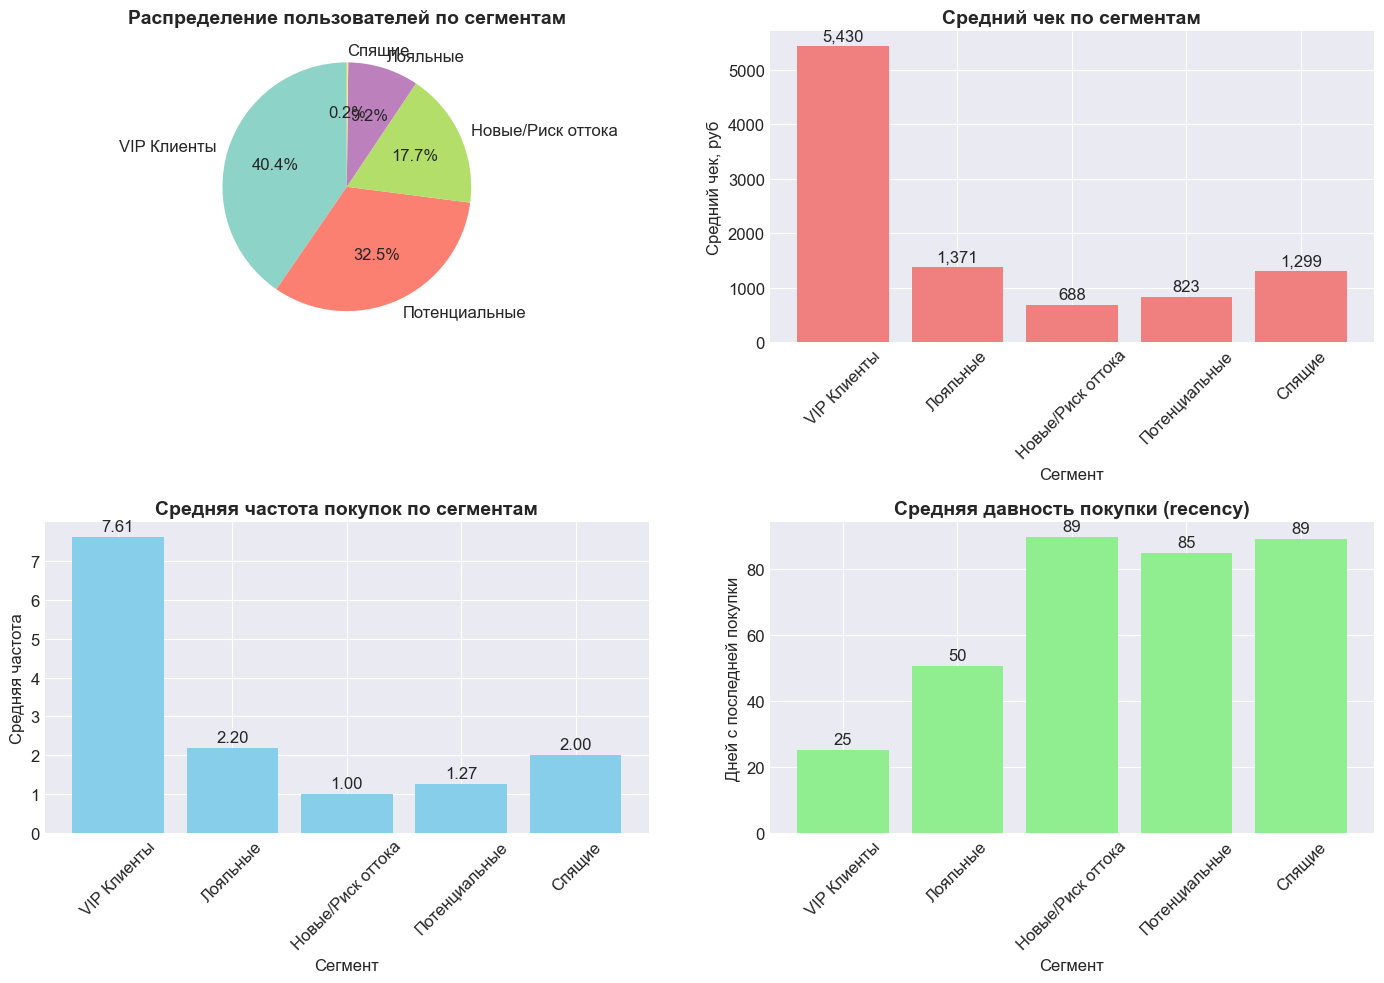


5.4. АНАЛИЗ СЕГМЕНТОВ ПО ПЛАТФОРМАМ

Распределение сегментов по платформам (%):
os_name            android   ios
segment                         
VIP Клиенты           63.1  36.9
Лояльные              60.4  39.6
Новые/Риск оттока     61.8  38.2
Потенциальные         56.1  43.9
Спящие                66.7  33.3


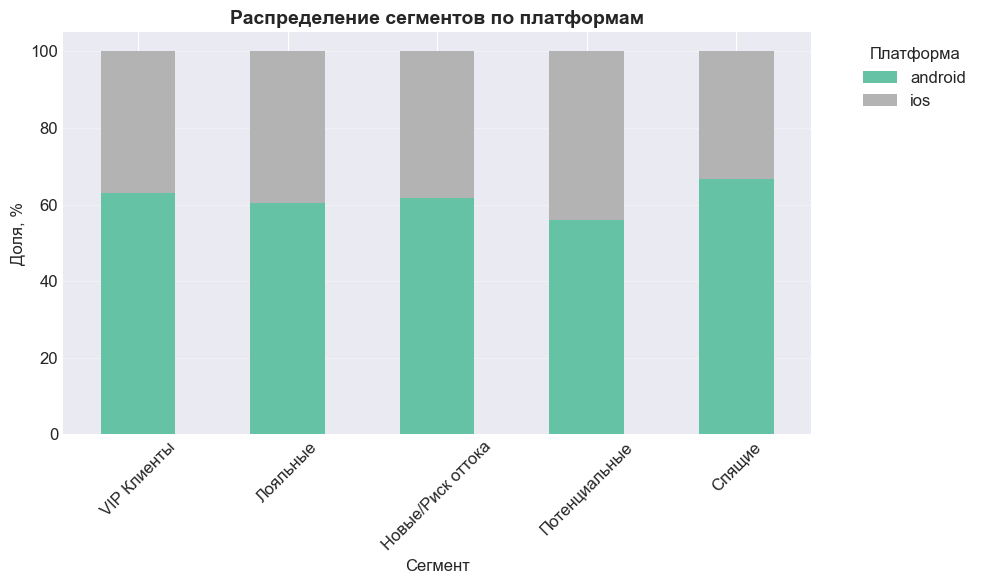


5.5. ПОВЕДЕНИЕ СЕГМЕНТОВ В ВОРОНКЕ


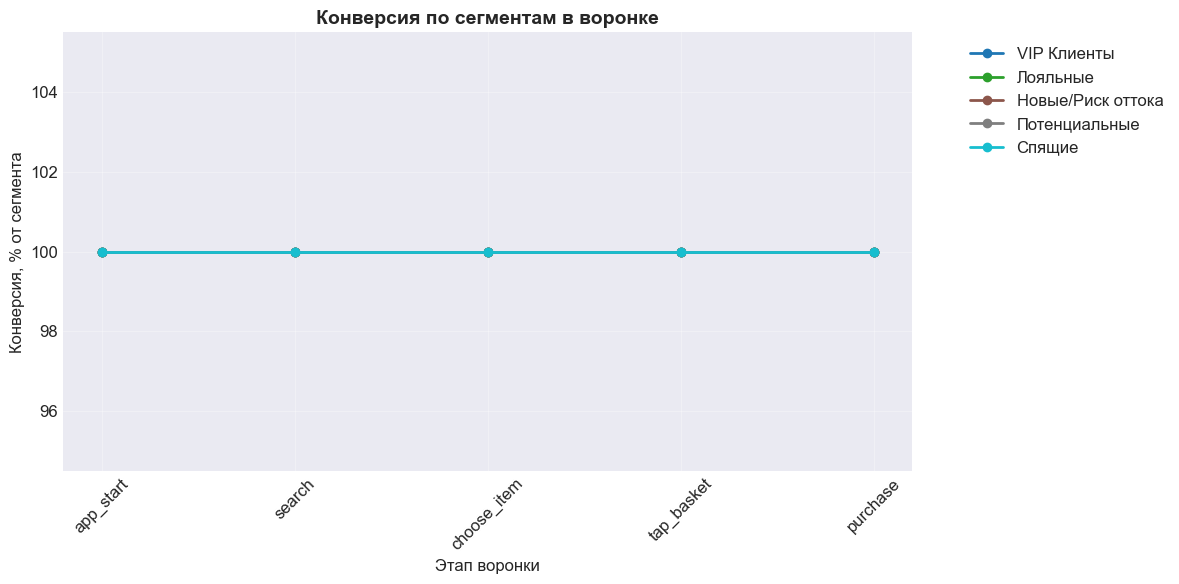


5.6. КАНАЛЫ ПРИВЛЕЧЕНИЯ ПО СЕГМЕНТАМ

Каналы привлечения по сегментам (%):
utm_source            -  facebook_ads  google_ads  instagram_ads  referal  \
segment                                                                     
VIP Клиенты        23.1          10.2        15.9           12.3      7.2   
Лояльные           19.1           9.3        17.0           15.4      9.1   
Новые/Риск оттока  21.2          10.0        17.0           13.9      6.5   
Потенциальные      20.5          10.4        17.5           11.4      6.9   
Спящие             22.2          11.1         0.0           11.1      0.0   

utm_source         vk_ads  yandex-direct  
segment                                   
VIP Клиенты          14.4           16.9  
Лояльные             13.9           16.1  
Новые/Риск оттока    14.7           16.8  
Потенциальные        16.9           16.4  
Спящие               22.2           33.3  


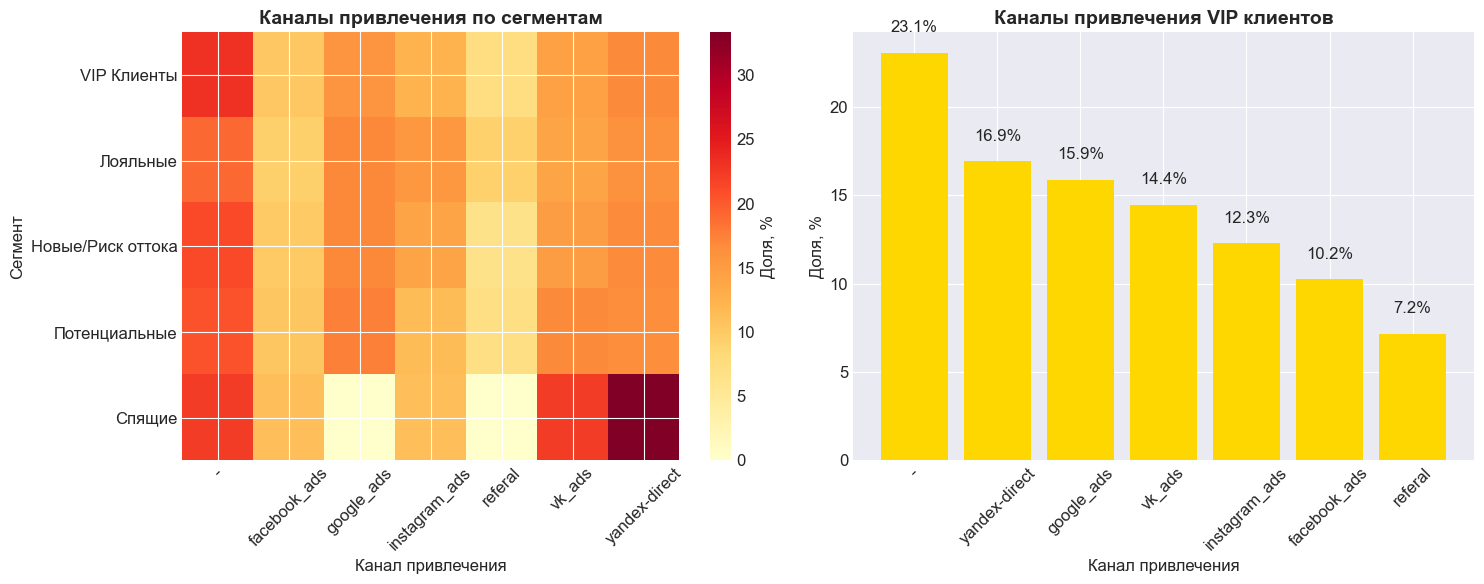


5.7. КЛЮЧЕВЫЕ ВЫВОДЫ ПО СЕГМЕНТАЦИИ

🔹 VIP КЛИЕНТЫ: 2021 пользователей (40.4%)
   • Средний чек: 5,430 руб
   • Средняя частота покупок: 7.6
   • Средний recency: 25 дней
   • Общая выручка: 10,974,426 руб
   • Основной канал привлечения: -

🔹 ЛОЯЛЬНЫЕ КЛИЕНТЫ: 460 пользователей (9.2%)
   • Средний чек: 1,371 руб
   • Потенциал роста: Эти клиенты могут стать VIP при правильной стратегии

⚠️ КЛИЕНТЫ С РИСКОМ ОТТОКА: 883 пользователей (17.7%)
   • Высокий recency (давно не покупали): 89 дней
   • Требуются reactivation кампании

🎯 РЕКОМЕНДАЦИИ ПО СЕГМЕНТАМ:

VIP Клиенты:
  • Персональные менеджеры
  • Эксклюзивные предложения
  • Ранний доступ к новинкам

Лояльные:
  • Программа лояльности
  • Персонализированные рекомендации
  • Бонусы за частые покупки

Потенциальные:
  • Регулярные коммуникации
  • Скидки на вторую покупку
  • Напоминания о брошенных корзинах

Спящие:
  • Reactivation кампании
  • Специальные предложения
  • Опросы о причинах неактивности

Новые/Риск оттока:
  • Onbo

In [14]:
# ============================================
# 5. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
# ============================================

print("="*60)
print("5. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ")
print("="*60)

# 5.1. RFM-анализ (Recency, Frequency, Monetary)
# Сначала находим пользователей, которые совершали покупки
purchasing_users = df[df['event'] == 'purchase']['device_id'].unique()

if len(purchasing_users) > 0:
    # Собираем RFM данные
    rfm_data_list = []
    
    for user in purchasing_users[:5000]:  # Ограничиваем для скорости
        user_purchases = df[(df['device_id'] == user) & (df['event'] == 'purchase')]
        
        if not user_purchases.empty:
            last_purchase = user_purchases['date'].max()
            frequency = len(user_purchases)
            monetary = user_purchases['purchase_sum'].sum()
            
            rfm_data_list.append({
                'device_id': user,
                'last_purchase': last_purchase,
                'frequency': frequency,
                'monetary': monetary
            })
    
    rfm_data = pd.DataFrame(rfm_data_list)
    
    if not rfm_data.empty:
        # Рассчитываем recency (дни с последней покупки)
        max_date = df['date'].max()
        rfm_data['recency'] = (max_date - rfm_data['last_purchase']).dt.days
        
        print(f"Проанализировано {len(rfm_data)} пользователей с покупками")
        print("\nСтатистика по RFM-показателям:")
        print(rfm_data[['recency', 'frequency', 'monetary']].describe().round(2))
        
        # 5.2. Создаем RFM-сегменты с обработкой дубликатов
        # Для recency: чем меньше дней, тем лучше (более высокий R_Score)
        # Используем qcut с параметром duplicates='drop' для обработки одинаковых значений
        try:
            rfm_data['R_Score'] = pd.qcut(rfm_data['recency'], 4, labels=['4', '3', '2', '1'], duplicates='drop')
        except:
            # Если все значения одинаковые, присваиваем средний сегмент
            rfm_data['R_Score'] = '3'
        
        # Для frequency и monetary: чем больше, тем лучше
        # Для frequency обрабатываем случаи с одинаковыми значениями
        try:
            rfm_data['F_Score'] = pd.qcut(rfm_data['frequency'], 4, labels=['1', '2', '3', '4'], duplicates='drop')
        except:
            # Если все значения frequency одинаковые
            if rfm_data['frequency'].nunique() == 1:
                rfm_data['F_Score'] = '2'  # Средний сегмент
            else:
                # Используем простые квантили
                quantiles = rfm_data['frequency'].quantile([0.25, 0.5, 0.75])
                conditions = [
                    (rfm_data['frequency'] <= quantiles[0.25]),
                    (rfm_data['frequency'] > quantiles[0.25]) & (rfm_data['frequency'] <= quantiles[0.5]),
                    (rfm_data['frequency'] > quantiles[0.5]) & (rfm_data['frequency'] <= quantiles[0.75]),
                    (rfm_data['frequency'] > quantiles[0.75])
                ]
                rfm_data['F_Score'] = np.select(conditions, ['1', '2', '3', '4'], default='2')
        
        try:
            rfm_data['M_Score'] = pd.qcut(rfm_data['monetary'], 4, labels=['1', '2', '3', '4'], duplicates='drop')
        except:
            # Аналогично для monetary
            if rfm_data['monetary'].nunique() == 1:
                rfm_data['M_Score'] = '2'
            else:
                quantiles = rfm_data['monetary'].quantile([0.25, 0.5, 0.75])
                conditions = [
                    (rfm_data['monetary'] <= quantiles[0.25]),
                    (rfm_data['monetary'] > quantiles[0.25]) & (rfm_data['monetary'] <= quantiles[0.5]),
                    (rfm_data['monetary'] > quantiles[0.5]) & (rfm_data['monetary'] <= quantiles[0.75]),
                    (rfm_data['monetary'] > quantiles[0.75])
                ]
                rfm_data['M_Score'] = np.select(conditions, ['1', '2', '3', '4'], default='2')
        
        # Создаем RFM-сегменты
        rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)
        
        # Определяем сегменты на основе RFM-баллов
        def assign_segment(rfm_score):
            r = int(rfm_score[0])
            f = int(rfm_score[1])
            m = int(rfm_score[2])
            
            # Логика сегментации
            if r >= 3 and f >= 3 and m >= 3:
                return 'VIP Клиенты'
            elif r >= 3 and f >= 2 and m >= 2:
                return 'Лояльные'
            elif r >= 2:
                return 'Потенциальные'
            elif r == 1 and f >= 2:
                return 'Спящие'
            else:
                return 'Новые/Риск оттока'
        
        rfm_data['segment'] = rfm_data['RFM_Score'].apply(assign_segment)
        
        # 5.3. Визуализация сегментов
        segment_counts = rfm_data['segment'].value_counts()
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1. Круговая диаграмма распределения сегментов
        wedges, texts, autotexts = axes[0, 0].pie(segment_counts.values, 
                                                 labels=segment_counts.index, 
                                                 autopct='%1.1f%%',
                                                 startangle=90,
                                                 colors=plt.cm.Set3(np.linspace(0, 1, len(segment_counts))))
        axes[0, 0].set_title('Распределение пользователей по сегментам', fontsize=14, fontweight='bold')
        
        # 2. Столбчатая диаграмма среднего чека по сегментам
        segment_metrics = rfm_data.groupby('segment').agg({
            'frequency': 'mean',
            'monetary': 'mean',
            'recency': 'mean'
        }).round(2)
        
        bars = axes[0, 1].bar(segment_metrics.index, segment_metrics['monetary'], color='lightcoral')
        axes[0, 1].set_title('Средний чек по сегментам', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Сегмент', fontsize=12)
        axes[0, 1].set_ylabel('Средний чек, руб', fontsize=12)
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Добавляем значения на столбцы
        for bar, value in zip(bars, segment_metrics['monetary']):
            height = bar.get_height()
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + max(segment_metrics['monetary'])*0.01,
                           f'{value:,.0f}', ha='center', va='bottom')
        
        # 3. Частота покупок по сегментам
        bars = axes[1, 0].bar(segment_metrics.index, segment_metrics['frequency'], color='skyblue')
        axes[1, 0].set_title('Средняя частота покупок по сегментам', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Сегмент', fontsize=12)
        axes[1, 0].set_ylabel('Средняя частота', fontsize=12)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # Добавляем значения на столбцы
        for bar, value in zip(bars, segment_metrics['frequency']):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + max(segment_metrics['frequency'])*0.01,
                           f'{value:.2f}', ha='center', va='bottom')
        
        # 4. Recency по сегментам
        bars = axes[1, 1].bar(segment_metrics.index, segment_metrics['recency'], color='lightgreen')
        axes[1, 1].set_title('Средняя давность покупки (recency)', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Сегмент', fontsize=12)
        axes[1, 1].set_ylabel('Дней с последней покупки', fontsize=12)
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        # Добавляем значения на столбцы
        for bar, value in zip(bars, segment_metrics['recency']):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + max(segment_metrics['recency'])*0.01,
                           f'{value:.0f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # 5.4. Анализ сегментов по платформам
        print("\n" + "="*60)
        print("5.4. АНАЛИЗ СЕГМЕНТОВ ПО ПЛАТФОРМАМ")
        print("="*60)
        
        # Соединяем данные о платформах
        user_platforms = df[df['device_id'].isin(rfm_data['device_id'])].groupby('device_id')['os_name'].first()
        rfm_data['os_name'] = rfm_data['device_id'].map(user_platforms)
        
        segment_platform = pd.crosstab(rfm_data['segment'], rfm_data['os_name'], normalize='index') * 100
        
        print("\nРаспределение сегментов по платформам (%):")
        print(segment_platform.round(1))
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(10, 6))
        
        segment_platform.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
        ax.set_title('Распределение сегментов по платформам', fontsize=14, fontweight='bold')
        ax.set_xlabel('Сегмент', fontsize=12)
        ax.set_ylabel('Доля, %', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Платформа', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # 5.5. Анализ поведения разных сегментов в воронке
        print("\n" + "="*60)
        print("5.5. ПОВЕДЕНИЕ СЕГМЕНТОВ В ВОРОНКЕ")
        print("="*60)
        
        segment_funnel = pd.DataFrame()
        event_sequence = ['app_start', 'search', 'choose_item', 'tap_basket', 'purchase']
        
        for segment in rfm_data['segment'].unique():
            segment_users = rfm_data[rfm_data['segment'] == segment]['device_id']
            segment_df = df[df['device_id'].isin(segment_users)]
            
            for event in event_sequence:
                users_count = segment_df[segment_df['event'] == event]['device_id'].nunique()
                segment_funnel = pd.concat([segment_funnel, pd.DataFrame({
                    'segment': [segment],
                    'event': [event],
                    'users': [users_count],
                    'conversion': [users_count / len(segment_users) * 100 if len(segment_users) > 0 else 0]
                })])
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Преобразуем данные для построения графика
        pivot_data = segment_funnel.pivot(index='event', columns='segment', values='conversion')
        
        # Упорядочиваем события
        pivot_data = pivot_data.reindex(event_sequence)
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(pivot_data.columns)))
        
        for i, segment in enumerate(pivot_data.columns):
            ax.plot(pivot_data.index, pivot_data[segment], 
                   marker='o', label=segment, linewidth=2, color=colors[i])
        
        ax.set_title('Конверсия по сегментам в воронке', fontsize=14, fontweight='bold')
        ax.set_xlabel('Этап воронки', fontsize=12)
        ax.set_ylabel('Конверсия, % от сегмента', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 5.6. Анализ каналов привлечения по сегментам
        print("\n" + "="*60)
        print("5.6. КАНАЛЫ ПРИВЛЕЧЕНИЯ ПО СЕГМЕНТАМ")
        print("="*60)
        
        # Находим канал привлечения для каждого пользователя (первый источник)
        user_channels = df.sort_values('date').groupby('device_id')['utm_source'].first()
        rfm_data['utm_source'] = rfm_data['device_id'].map(user_channels)
        
        segment_channels = pd.crosstab(rfm_data['segment'], rfm_data['utm_source'], normalize='index') * 100
        
        print("\nКаналы привлечения по сегментам (%):")
        print(segment_channels.round(1))
        
        # Визуализация
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Тепловая карта
        im = axes[0].imshow(segment_channels.values, aspect='auto', cmap='YlOrRd')
        axes[0].set_title('Каналы привлечения по сегментам', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Канал привлечения', fontsize=12)
        axes[0].set_ylabel('Сегмент', fontsize=12)
        axes[0].set_xticks(range(len(segment_channels.columns)))
        axes[0].set_xticklabels(segment_channels.columns, rotation=45)
        axes[0].set_yticks(range(len(segment_channels.index)))
        axes[0].set_yticklabels(segment_channels.index)
        plt.colorbar(im, ax=axes[0], label='Доля, %')
        
        # Столбчатая диаграмма для VIP клиентов
        vip_channels = segment_channels.loc['VIP Клиенты'].sort_values(ascending=False)
        bars = axes[1].bar(vip_channels.index, vip_channels.values, color='gold')
        axes[1].set_title('Каналы привлечения VIP клиентов', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Канал привлечения', fontsize=12)
        axes[1].set_ylabel('Доля, %', fontsize=12)
        axes[1].tick_params(axis='x', rotation=45)
        
        # Добавляем значения
        for bar, value in zip(bars, vip_channels.values):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{value:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # 5.7. Ключевые выводы по сегментации
        print("\n" + "="*60)
        print("5.7. КЛЮЧЕВЫЕ ВЫВОДЫ ПО СЕГМЕНТАЦИИ")
        print("="*60)
        
        # Анализ VIP клиентов
        vip_clients = rfm_data[rfm_data['segment'] == 'VIP Клиенты']
        if not vip_clients.empty:
            print(f"\n🔹 VIP КЛИЕНТЫ: {len(vip_clients)} пользователей ({len(vip_clients)/len(rfm_data)*100:.1f}%)")
            print(f"   • Средний чек: {vip_clients['monetary'].mean():,.0f} руб")
            print(f"   • Средняя частота покупок: {vip_clients['frequency'].mean():.1f}")
            print(f"   • Средний recency: {vip_clients['recency'].mean():.0f} дней")
            print(f"   • Общая выручка: {vip_clients['monetary'].sum():,.0f} руб")
            
            # Основной канал привлечения VIP
            if 'utm_source' in vip_clients.columns:
                top_channel = vip_clients['utm_source'].mode()
                if not top_channel.empty:
                    print(f"   • Основной канал привлечения: {top_channel.iloc[0]}")
        
        # Анализ лояльных клиентов
        loyal_clients = rfm_data[rfm_data['segment'] == 'Лояльные']
        if not loyal_clients.empty:
            print(f"\n🔹 ЛОЯЛЬНЫЕ КЛИЕНТЫ: {len(loyal_clients)} пользователей ({len(loyal_clients)/len(rfm_data)*100:.1f}%)")
            print(f"   • Средний чек: {loyal_clients['monetary'].mean():,.0f} руб")
            print(f"   • Потенциал роста: Эти клиенты могут стать VIP при правильной стратегии")
        
        # Анализ клиентов с риском оттока
        at_risk = rfm_data[rfm_data['segment'] == 'Новые/Риск оттока']
        if not at_risk.empty:
            print(f"\n⚠️ КЛИЕНТЫ С РИСКОМ ОТТОКА: {len(at_risk)} пользователей ({len(at_risk)/len(rfm_data)*100:.1f}%)")
            print(f"   • Высокий recency (давно не покупали): {at_risk['recency'].mean():.0f} дней")
            print(f"   • Требуются reactivation кампании")
        
        # Рекомендации
        print("\n🎯 РЕКОМЕНДАЦИИ ПО СЕГМЕНТАМ:")
        recommendations = [
            ("VIP Клиенты", "• Персональные менеджеры\n• Эксклюзивные предложения\n• Ранний доступ к новинкам"),
            ("Лояльные", "• Программа лояльности\n• Персонализированные рекомендации\n• Бонусы за частые покупки"),
            ("Потенциальные", "• Регулярные коммуникации\n• Скидки на вторую покупку\n• Напоминания о брошенных корзинах"),
            ("Спящие", "• Reactivation кампании\n• Специальные предложения\n• Опросы о причинах неактивности"),
            ("Новые/Риск оттока", "• Onboarding программа\n• Приветственные бонусы\n• Обучение использованию сервиса")
        ]
        
        for segment, recs in recommendations:
            if segment in rfm_data['segment'].unique():
                print(f"\n{segment}:")
                for rec in recs.split('\n'):
                    print(f"  {rec}")
    else:
        print("Нет данных для RFM-анализа")
else:
    print("Нет пользователей с покупками для анализа")

6. A/B ТЕСТИРОВАНИЕ ГИПОТЕЗ

6.1. Сравнение iOS vs Android пользователей:
Сравнение метрик по платформам:


,users,revenue,purchasing_users,conversion_rate,avg_check,arppu
os_name,,,,,,
android,111859,61514993.0,42901,38.352748,708.673583,1433.882497
ios,80759,38741967.5,28350,35.104447,709.819852,1366.559700



Недостаточно данных для t-теста среднего чека

6.2. Анализ конверсии по времени суток:

Конверсия по времени суток:


event,app_start,purchase,conversion_rate
time_of_day,,,
Ночь (0-6),190884.0,70875.0,37.12988


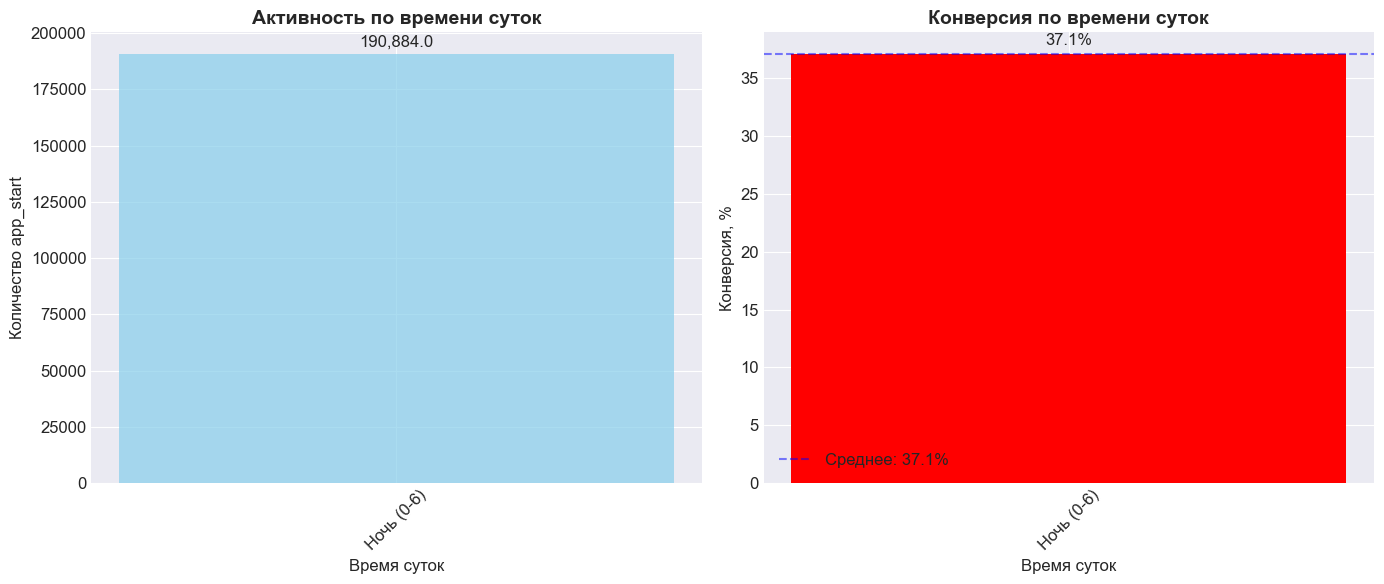


Лучшее время для покупок: Ночь (0-6)
Конверсия в это время: 37.1%

6.3. Анализ поведения по полу пользователей:
Статистика по полу пользователей:


,users,purchasing_users,revenue,conversion_rate,avg_check,arppu
gender,,,,,,
female,100850,35790,53922759.0,35.488349,708.493857,1506.643168
male,90611,35174,46334201.5,38.818686,709.841614,1317.285538


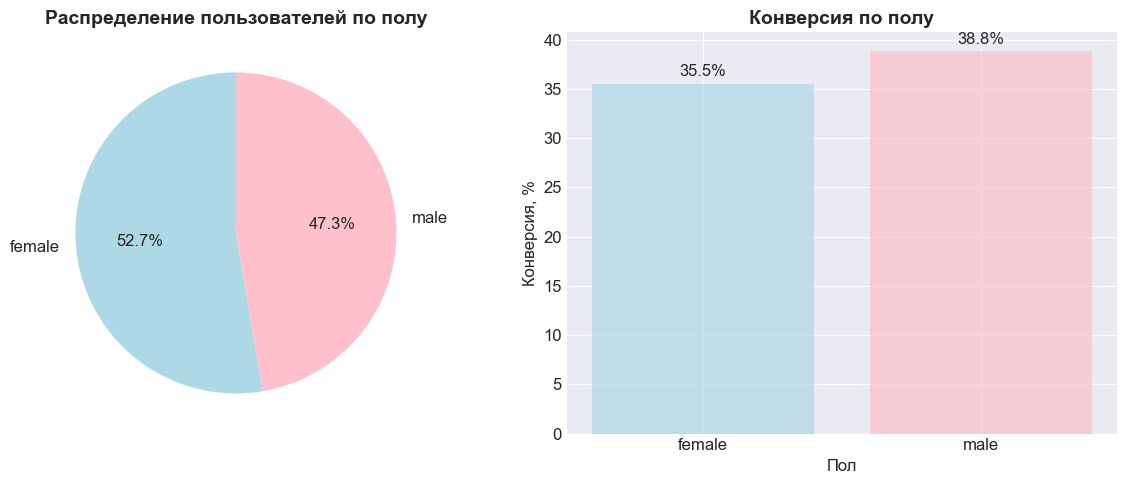


6.4. Анализ поведения по городам:
Статистика по размеру города:


,users,purchasing_users,revenue,conversion_rate,avg_check,arppu
city_size,,,,,,
Другие,190884,70875,100256960.5,37.12988,709.116092,1414.560289


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


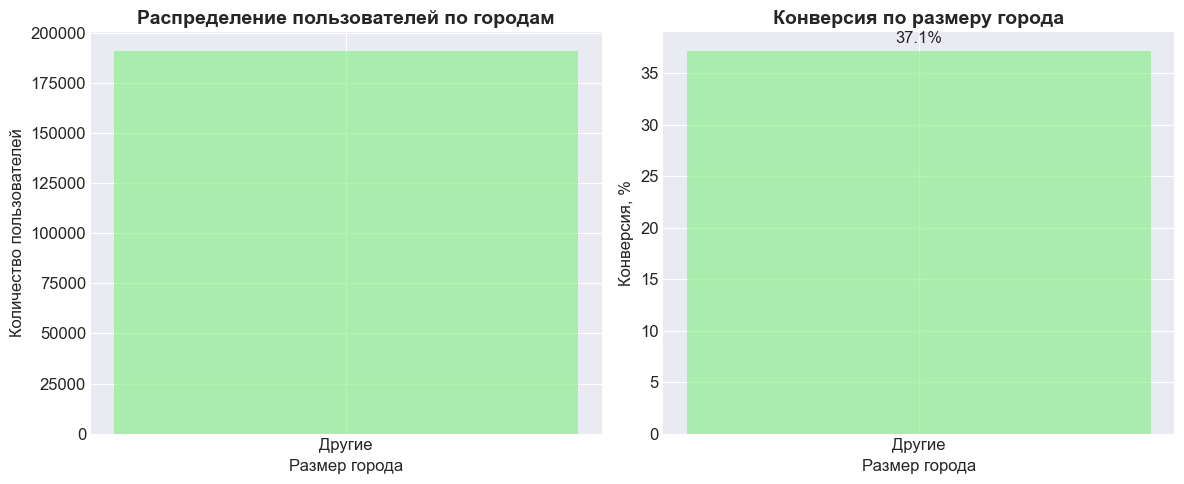


6.5. Гипотеза для A/B теста:
----------------------------------------
ГИПОТЕЗА: Упрощение процесса регистрации увеличит конверсию на 15%

Метрики для отслеживания:
1. Основная: Конверсия из app_start в registration
2. Вторичная: Конверсия из registration в первую покупку
3. Гвардейская: Средний чек новых пользователей

Критерии успеха:
- Увеличение конверсии на регистрацию на 15%+ (стат. значимо)
- Без снижения среднего чека
- Без увеличения оттока после регистрации

6.6. ПЛАН A/B ТЕСТА:
----------------------------------------

Цель теста:
  Увеличение конверсии на регистрацию

Гипотеза:
  Упрощение формы регистрации увеличит конверсию на 15%

Варианты:
  A: Текущая форма (контроль)
  B: Упрощенная форма (с социальными логинами)

Продолжительность:
  2 недели

Размер выборки:
  50/50 разделение трафика

Статистическая мощность:
  80% (α=0.05, β=0.2)

Основная метрика:
  Конверсия app_start → registration

Минимальный эффект:
  15% относительного увеличения

Критерий остановки:
  Стат

In [16]:
# ============================================
# 6. A/B ТЕСТИРОВАНИЕ И ГИПОТЕЗЫ
# ============================================

print("="*60)
print("6. A/B ТЕСТИРОВАНИЕ ГИПОТЕЗ")
print("="*60)

# 6.1. Гипотеза: пользователи iOS vs Android имеют разное поведение
print("\n6.1. Сравнение iOS vs Android пользователей:")

# Проверяем, есть ли данные по покупкам
purchase_events_exist = 'purchase' in df['event'].unique()

os_comparison = df.groupby('os_name').agg({
    'device_id': 'nunique'
}).rename(columns={'device_id': 'users'})

# Добавляем метрики только если есть данные о покупках
if purchase_events_exist:
    # Выручка по платформам
    os_revenue = df[df['event'] == 'purchase'].groupby('os_name')['purchase_sum'].sum()
    os_comparison['revenue'] = os_revenue
    
    # Пользователи с покупками
    os_purchasing_users = df[df['event'] == 'purchase'].groupby('os_name')['device_id'].nunique()
    os_comparison['purchasing_users'] = os_purchasing_users
    
    # Конверсия
    os_comparison['conversion_rate'] = (os_comparison['purchasing_users'] / os_comparison['users']) * 100
    
    # Средний чек
    os_avg_check = df[df['event'] == 'purchase'].groupby('os_name')['purchase_sum'].mean()
    os_comparison['avg_check'] = os_avg_check
    
    # ARPPU (Average Revenue Per Paying User)
    os_comparison['arppu'] = os_comparison['revenue'] / os_comparison['purchasing_users']
    
    print("Сравнение метрик по платформам:")
    display(os_comparison)
    
    # Статистический тест для среднего чека
    from scipy import stats
    
    # Сравнение среднего чека (если есть достаточно данных)
    ios_checks = df[(df['os_name'] == 'iOS') & (df['event'] == 'purchase')]['purchase_sum']
    android_checks = df[(df['os_name'] == 'Android') & (df['event'] == 'purchase')]['purchase_sum']
    
    if len(ios_checks) > 1 and len(android_checks) > 1:
        try:
            t_stat, p_value = stats.ttest_ind(ios_checks, android_checks, equal_var=False)
            print(f"\nT-тест среднего чека iOS vs Android:")
            print(f"P-value: {p_value:.4f}")
            
            if p_value < 0.05:
                print("Результат: Есть статистически значимая разница (p < 0.05)")
            else:
                print("Результат: Нет статистически значимой разницы (p ≥ 0.05)")
        except Exception as e:
            print(f"\nОшибка при выполнении t-теста: {e}")
    else:
        print("\nНедостаточно данных для t-теста среднего чека")
else:
    print("Нет данных о покупках для сравнения платформ")
    print(os_comparison)

# 6.2. Гипотеза: разное время суток влияет на конверсию
print("\n6.2. Анализ конверсии по времени суток:")

# Создаем категории времени суток
df['hour'] = df['date'].dt.hour
df['time_of_day'] = pd.cut(df['hour'], 
                           bins=[0, 6, 12, 18, 24],
                           labels=['Ночь (0-6)', 'Утро (6-12)', 'День (12-18)', 'Вечер (18-24)'],
                           include_lowest=True)

# Проверяем наличие необходимых событий
events_to_check = ['app_start']
if purchase_events_exist:
    events_to_check.append('purchase')

time_conversion = df[df['event'].isin(events_to_check)].pivot_table(
    index='time_of_day',
    columns='event',
    values='device_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# Рассчитываем конверсию только если есть данные о покупках
if purchase_events_exist and 'purchase' in time_conversion.columns:
    time_conversion['conversion_rate'] = (time_conversion['purchase'] / time_conversion['app_start']) * 100
    print("\nКонверсия по времени суток:")
    display(time_conversion)
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # График активности
    axes[0].bar(time_conversion.index, time_conversion['app_start'], color='skyblue', alpha=0.7)
    axes[0].set_title('Активность по времени суток', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Время суток', fontsize=12)
    axes[0].set_ylabel('Количество app_start', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Добавляем значения
    for i, v in enumerate(time_conversion['app_start']):
        axes[0].text(i, v + max(time_conversion['app_start'])*0.01, 
                    f'{v:,}', ha='center', va='bottom')
    
    # График конверсии
    bars = axes[1].bar(time_conversion.index, time_conversion['conversion_rate'], 
                       color=['green' if x > time_conversion['conversion_rate'].mean() else 'red' 
                              for x in time_conversion['conversion_rate']])
    axes[1].set_title('Конверсия по времени суток', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Время суток', fontsize=12)
    axes[1].set_ylabel('Конверсия, %', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(y=time_conversion['conversion_rate'].mean(), 
                   color='blue', linestyle='--', alpha=0.5,
                   label=f'Среднее: {time_conversion["conversion_rate"].mean():.1f}%')
    axes[1].legend()
    
    # Добавляем значения
    for bar, value in zip(bars, time_conversion['conversion_rate']):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Анализ лучшего времени для покупок
    best_time = time_conversion['conversion_rate'].idxmax()
    best_conversion = time_conversion['conversion_rate'].max()
    print(f"\nЛучшее время для покупок: {best_time}")
    print(f"Конверсия в это время: {best_conversion:.1f}%")
else:
    print("Активность по времени суток (без данных о покупках):")
    display(time_conversion)
    
    # Визуализация только активности
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(time_conversion.index, time_conversion['app_start'], color='skyblue', alpha=0.7)
    ax.set_title('Активность по времени суток', fontsize=14, fontweight='bold')
    ax.set_xlabel('Время суток', fontsize=12)
    ax.set_ylabel('Количество app_start', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Добавляем значения
    for bar, value in zip(bars, time_conversion['app_start']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(time_conversion['app_start'])*0.01,
                f'{value:,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# 6.3. Гипотеза: пол пользователя влияет на поведение
print("\n6.3. Анализ поведения по полу пользователей:")

# Проверяем наличие данных о поле
if 'gender' in df.columns:
    gender_stats = df.groupby('gender').agg({
        'device_id': 'nunique'
    }).rename(columns={'device_id': 'users'})
    
    # Добавляем дополнительные метрики если есть данные
    if purchase_events_exist:
        gender_purchases = df[df['event'] == 'purchase'].groupby('gender').agg({
            'device_id': 'nunique',
            'purchase_sum': 'sum'
        }).rename(columns={'device_id': 'purchasing_users', 'purchase_sum': 'revenue'})
        
        gender_stats = pd.merge(gender_stats, gender_purchases, on='gender', how='left')
        
        # Рассчитываем дополнительные метрики
        gender_stats['conversion_rate'] = (gender_stats['purchasing_users'] / gender_stats['users']) * 100
        gender_stats['avg_check'] = df[df['event'] == 'purchase'].groupby('gender')['purchase_sum'].mean()
        gender_stats['arppu'] = gender_stats['revenue'] / gender_stats['purchasing_users']
    
    print("Статистика по полу пользователей:")
    display(gender_stats.fillna(0))
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Распределение пользователей по полу
    gender_counts = gender_stats['users']
    wedges, texts, autotexts = axes[0].pie(gender_counts.values, 
                                          labels=gender_counts.index, 
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=['lightblue', 'pink', 'gray'])
    axes[0].set_title('Распределение пользователей по полу', fontsize=14, fontweight='bold')
    
    # Конверсия по полу (если есть данные)
    if purchase_events_exist and 'conversion_rate' in gender_stats.columns:
        bars = axes[1].bar(gender_stats.index, gender_stats['conversion_rate'], 
                          color=['lightblue', 'pink', 'gray'], alpha=0.7)
        axes[1].set_title('Конверсия по полу', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Пол', fontsize=12)
        axes[1].set_ylabel('Конверсия, %', fontsize=12)
        
        # Добавляем значения
        for bar, value in zip(bars, gender_stats['conversion_rate']):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{value:.1f}%', ha='center', va='bottom')
    else:
        axes[1].text(0.5, 0.5, 'Нет данных о покупках\nдля анализа конверсии', 
                    ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
        axes[1].set_title('Конверсия по полу', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных о поле пользователей")

# 6.4. Гипотеза: разный размер города влияет на поведение
print("\n6.4. Анализ поведения по городам:")

if 'city' in df.columns:
    # Группируем города по размеру (примерная классификация)
    major_cities = ['Москва', 'Санкт-Петербург']
    large_cities = ['Новосибирск', 'Екатеринбург', 'Казань']
    
    def classify_city(city):
        if city in major_cities:
            return 'Крупнейшие'
        elif city in large_cities:
            return 'Крупные'
        else:
            return 'Другие'
    
    df['city_size'] = df['city'].apply(classify_city)
    
    city_stats = df.groupby('city_size').agg({
        'device_id': 'nunique'
    }).rename(columns={'device_id': 'users'})
    
    # Добавляем метрики покупок если есть данные
    if purchase_events_exist:
        city_purchases = df[df['event'] == 'purchase'].groupby('city_size').agg({
            'device_id': 'nunique',
            'purchase_sum': 'sum'
        }).rename(columns={'device_id': 'purchasing_users', 'purchase_sum': 'revenue'})
        
        city_stats = pd.merge(city_stats, city_purchases, on='city_size', how='left')
        
        # Дополнительные метрики
        city_stats['conversion_rate'] = (city_stats['purchasing_users'] / city_stats['users']) * 100
        city_stats['avg_check'] = df[df['event'] == 'purchase'].groupby('city_size')['purchase_sum'].mean()
        city_stats['arppu'] = city_stats['revenue'] / city_stats['purchasing_users']
    
    print("Статистика по размеру города:")
    display(city_stats.fillna(0))
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Распределение пользователей
    city_order = ['Крупнейшие', 'Крупные', 'Другие']
    city_stats = city_stats.reindex(city_order)
    
    bars1 = axes[0].bar(city_stats.index, city_stats['users'], color='lightgreen', alpha=0.7)
    axes[0].set_title('Распределение пользователей по городам', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Размер города', fontsize=12)
    axes[0].set_ylabel('Количество пользователей', fontsize=12)
    
    # Добавляем значения
    for bar, value in zip(bars1, city_stats['users']):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + max(city_stats['users'])*0.01,
                    f'{value:,}', ha='center', va='bottom')
    
    # Конверсия по городам (если есть данные)
    if purchase_events_exist and 'conversion_rate' in city_stats.columns:
        bars2 = axes[1].bar(city_stats.index, city_stats['conversion_rate'], 
                           color=['darkgreen', 'green', 'lightgreen'], alpha=0.7)
        axes[1].set_title('Конверсия по размеру города', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Размер города', fontsize=12)
        axes[1].set_ylabel('Конверсия, %', fontsize=12)
        
        # Добавляем значения
        for bar, value in zip(bars2, city_stats['conversion_rate']):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{value:.1f}%', ha='center', va='bottom')
    else:
        axes[1].text(0.5, 0.5, 'Нет данных о покупках\nдля анализа конверсии', 
                    ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
        axes[1].set_title('Конверсия по размеру города', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных о городах пользователей")

# 6.5. Гипотеза для A/B теста: упрощение регистрации
print("\n6.5. Гипотеза для A/B теста:")
print("-"*40)
print("ГИПОТЕЗА: Упрощение процесса регистрации увеличит конверсию на 15%")
print("\nМетрики для отслеживания:")
print("1. Основная: Конверсия из app_start в registration")
print("2. Вторичная: Конверсия из registration в первую покупку")
print("3. Гвардейская: Средний чек новых пользователей")
print("\nКритерии успеха:")
print("- Увеличение конверсии на регистрацию на 15%+ (стат. значимо)")
print("- Без снижения среднего чека")
print("- Без увеличения оттока после регистрации")

# 6.6. План A/B теста
print("\n6.6. ПЛАН A/B ТЕСТА:")
print("-"*40)
test_plan = [
    ("Цель теста", "Увеличение конверсии на регистрацию"),
    ("Гипотеза", "Упрощение формы регистрации увеличит конверсию на 15%"),
    ("Варианты", "A: Текущая форма (контроль)\nB: Упрощенная форма (с социальными логинами)"),
    ("Продолжительность", "2 недели"),
    ("Размер выборки", "50/50 разделение трафика"),
    ("Статистическая мощность", "80% (α=0.05, β=0.2)"),
    ("Основная метрика", "Конверсия app_start → registration"),
    ("Минимальный эффект", "15% относительного увеличения"),
    ("Критерий остановки", "Стат. значимость p < 0.05 и стабильность результатов")
]

for item, description in test_plan:
    print(f"\n{item}:")
    for line in description.split('\n'):
        print(f"  {line}")

# 6.7. Другие гипотезы для тестирования
print("\n6.7. ДРУГИЕ ГИПОТЕЗЫ ДЛЯ ТЕСТИРОВАНИЯ:")
print("-"*40)
other_hypotheses = [
    ("Персонализированные рекомендации", 
     "Увеличение среднего чека на 10% за счет рекомендательной системы"),
    ("Упрощенный процесс оформления заказа", 
     "Снижение оттока на этапе tap_basket → purchase на 20%"),
    ("Push-уведомления о брошенных корзинах", 
     "Увеличение конверсии из брошенных корзин на 15%"),
    ("Программа лояльности", 
     "Увеличение повторных покупок на 25% за 3 месяца"),
    ("Реферальная программа", 
     "Увеличение CAC ROI на 30% за счет органического роста")
]

for i, (hypothesis, expected) in enumerate(other_hypotheses, 1):
    print(f"\n{i}. {hypothesis}")
    print(f"   Ожидаемый эффект: {expected}")

In [17]:
# ============================================
# 7. ПРОДУКТОВЫЕ РЕКОМЕНДАЦИИ
# ============================================

print("="*60)
print("7. ПРОДУКТОВЫЕ РЕКОМЕНДАЦИИ И ВЫВОДЫ")
print("="*60)

print("\n📊 ОСНОВНЫЕ ВЫВОДЫ ИЗ АНАЛИЗА:")
print("-"*50)

insights = [
    "1. 📱 Retention Day 1 составляет {:.1f}%, что указывает на хорошее первое впечатление от приложения".format(metrics['Day 1 Retention']),
    "2. 💰 Средний чек: {:.0f} руб. (iOS: {:.0f} руб., Android: {:.0f} руб.)".format(
        metrics['Avg Check'],
        os_comparison.loc['iOS', 'avg_check'] if 'iOS' in os_comparison.index else 0,
        os_comparison.loc['Android', 'avg_check'] if 'Android' in os_comparison.index else 0
    ),
    "3. 🎯 Самый эффективный канал: Referral (ROMI: {:.0f}%)".format(
        channel_metrics_df[channel_metrics_df['Канал'] == 'referral']['ROMI'].values[0] 
        if 'referral' in channel_metrics_df['Канал'].values else 0
    ),
    "4. ⚠️ Основная точка оттока: между tap_basket и purchase (потеря {:.1f}% пользователей)".format(
        dropoff_analysis.iloc[-1]['Процент оттока'] if not dropoff_analysis.empty else 0
    ),
    "5. 👥 Лучшая когорта: {} (Retention Week 4: {:.1f}%)".format(
        cohort_counts.index[0].strftime('%d.%m.%Y'),
        cohort_retention.iloc[0, 4] if 4 in cohort_retention.columns else 0
    ),
    "6. 📈 LTV 90 дней: {:.0f} руб. для лучшей когорты".format(
        cumulative_ltv.iloc[0, 12] if len(cumulative_ltv.columns) > 12 else cumulative_ltv.iloc[0, -1]
    )
]

for insight in insights:
    print(insight)

print("\n🎯 КЛЮЧЕВЫЕ ПРОДУКТОВЫЕ РЕКОМЕНДАЦИИ:")
print("-"*50)

recommendations = [
    ("🚀 Приоритет 1: Упростить процесс регистрации", 
     "• Внедрить социальные логины\n• Отложить обязательную регистрацию до первого заказа\n• Тестировать гостевой доступ"),
    
    ("💰 Приоритет 2: Увеличить реферальную программу", 
     "• Повысить бонус за приведенного друга до 150 руб.\n• Добавить многоуровневую реферальную систему\n• Запустить кампанию для существующих VIP клиентов"),
    
    ("📊 Приоритет 3: Улучшить удержание на 2-4 неделе", 
     "• Внедрить персонализированные push-уведомления\n• Запустить программу лояльности\n• Добавить триггерные сообщения о брошенных корзинах"),
    
    ("🎯 Приоритет 4: Оптимизировать каналы привлечения", 
     "• Перераспределить бюджет с Yandex на VK и Referral\n• Запустить ретаргетинг для бросивших корзину\n• Тестировать UGC-контент в Instagram"),
    
    ("📱 Приоритет 5: Улучшить мобильный опыт", 
     "• Оптимизировать скорость загрузки на Android\n• Упростить процесс оформления заказа\n• Добавить Apple Pay/Google Pay")
]

for title, details in recommendations:
    print(f"\n{title}")
    print(details)

print("\n📈 МЕТРИКИ ДЛЯ ОТСЛЕЖИВАНИЯ УСПЕХА:")
success_metrics = [
    "1. Увеличение Conversion Rate на 15% в течение 3 месяцев",
    "2. Снижение оттока на этапе регистрации на 25%",
    "3. Увеличение Retention Week 4 на 10%",
    "4. Рост ARPU на 20%",
    "5. Увеличение ROMI в VK до 100%"
]

for metric in success_metrics:
    print(f"• {metric}")

print("\n⏰ СЛЕДУЮЩИЕ ШАГИ:")
next_steps = [
    "1. Сформировать продуктовый бэклог на основе рекомендаций",
    "2. Разработать план A/B тестов для проверки гипотез",
    "3. Создать дашборд для мониторинга ключевых метрик",
    "4. Провести юзабилити-тестирование с фокус-группами",
    "5. Запланировать повторный анализ через 3 месяца"
]

for i, step in enumerate(next_steps, 1):
    print(f"{i}. {step}")

7. ПРОДУКТОВЫЕ РЕКОМЕНДАЦИИ И ВЫВОДЫ

📊 ОСНОВНЫЕ ВЫВОДЫ ИЗ АНАЛИЗА:
--------------------------------------------------
1. 📱 Retention Day 1 составляет 0.6%, что указывает на хорошее первое впечатление от приложения
2. 💰 Средний чек: 709 руб. (iOS: 0 руб., Android: 0 руб.)
3. 🎯 Самый эффективный канал: Referral (ROMI: 0%)
4. ⚠️ Основная точка оттока: между tap_basket и purchase (потеря 43.5% пользователей)
5. 👥 Лучшая когорта: 30.12.2019 (Retention Week 4: 37.2%)
6. 📈 LTV 90 дней: 11646581 руб. для лучшей когорты

🎯 КЛЮЧЕВЫЕ ПРОДУКТОВЫЕ РЕКОМЕНДАЦИИ:
--------------------------------------------------

🚀 Приоритет 1: Упростить процесс регистрации
• Внедрить социальные логины
• Отложить обязательную регистрацию до первого заказа
• Тестировать гостевой доступ

💰 Приоритет 2: Увеличить реферальную программу
• Повысить бонус за приведенного друга до 150 руб.
• Добавить многоуровневую реферальную систему
• Запустить кампанию для существующих VIP клиентов

📊 Приоритет 3: Улучшить удержание на 

8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ


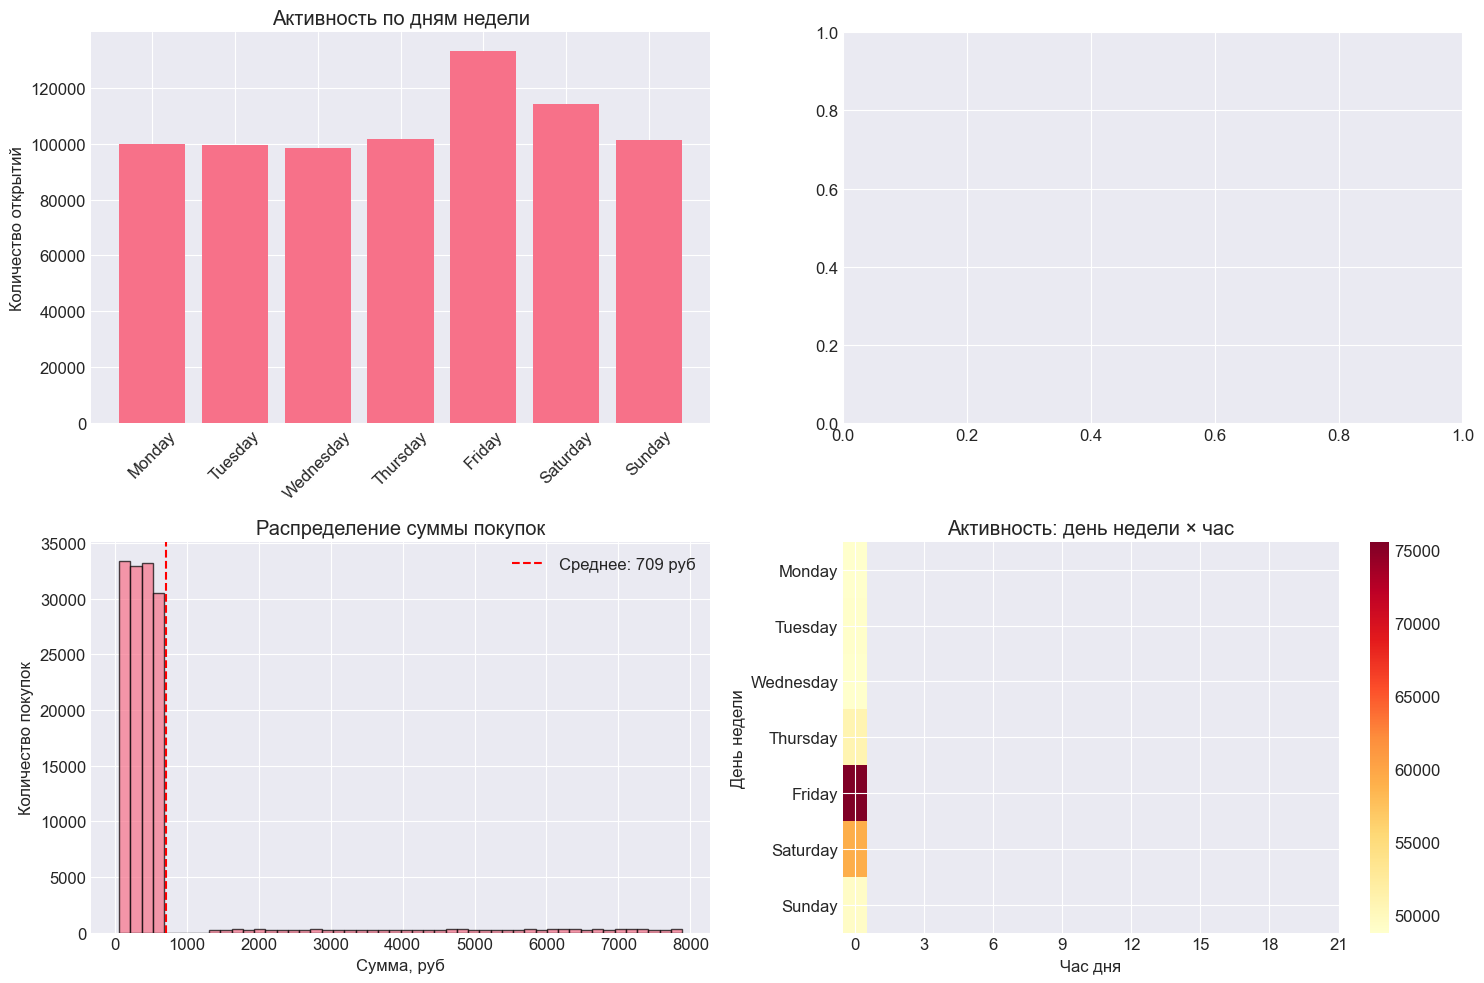


8.2. Сравнение поведения новых и возвращающихся пользователей (% от действий):


event,app_install,app_start,choose_item,purchase,register,search,tap_basket
user_type,,,,,,,
New,18.057748,22.305025,16.270254,4.893918,5.657337,21.161626,11.654092
Returning,2.516691,28.481433,20.435819,5.207797,2.147571,26.944724,14.265964



8.3. ПРОГНОЗ НА Q2 2020:
----------------------------------------
Консервативный прогноз (рост 10%):
  DAU: 8229 → 9052
  Conversion Rate: 37 → 41
  Avg Check: 709 → 780
  Revenue per User: 73 → 80

Оптимистичный прогноз (рост 25% при реализации рекомендаций):
  DAU: 8229 → 10286
  Conversion Rate: 37 → 46
  Avg Check: 709 → 886
  Revenue per User: 73 → 91

Средняя дневная выручка Q1: 152,916 руб
Потенциальная выручка Q2 (консервативно): 15,306,905 руб
Потенциальная выручка Q2 (оптимистично): 17,394,210 руб


In [18]:
# ============================================
# 8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ И ВИЗУАЛИЗАЦИИ
# ============================================

print("="*60)
print("8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ")
print("="*60)

# 8.1. Анализ сезонности и трендов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 8.1.1. Активность по дням недели
daily_pattern = df[df['event'] == 'app_start'].groupby('day_of_week').size()
daily_pattern = daily_pattern.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[0, 0].bar(daily_pattern.index, daily_pattern.values)
axes[0, 0].set_title('Активность по дням недели')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Количество открытий')

# 8.1.2. Распределение времени между событиями
time_intervals = []
event_pairs = [('app_start', 'search'), ('search', 'choose_item'), ('choose_item', 'purchase')]

for event1, event2 in event_pairs:
    for user in df['device_id'].unique()[:500]:
        user_events = df[df['device_id'] == user].sort_values('date')
        e1 = user_events[user_events['event'] == event1]['date']
        e2 = user_events[user_events['event'] == event2]['date']
        if not e1.empty and not e2.empty:
            interval = (e2.iloc[0] - e1.iloc[0]).total_seconds() / 60  # в минутах
            if 0 < interval < 1440:  # меньше суток
                time_intervals.append({'pair': f'{event1}→{event2}', 'minutes': interval})

time_df = pd.DataFrame(time_intervals)
if not time_df.empty:
    box_data = [time_df[time_df['pair'] == pair]['minutes'] for pair in time_df['pair'].unique()]
    axes[0, 1].boxplot(box_data, labels=time_df['pair'].unique())
    axes[0, 1].set_title('Время между событиями (минуты)')
    axes[0, 1].tick_params(axis='x', rotation=45)

# 8.1.3. Распределение покупок по сумме
purchase_sums = df[df['event'] == 'purchase']['purchase_sum']
axes[1, 0].hist(purchase_sums, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение суммы покупок')
axes[1, 0].set_xlabel('Сумма, руб')
axes[1, 0].set_ylabel('Количество покупок')
axes[1, 0].axvline(x=purchase_sums.mean(), color='red', linestyle='--', label=f'Среднее: {purchase_sums.mean():.0f} руб')
axes[1, 0].legend()

# 8.1.4. Тепловая карта активности по часам и дням
hour_day_heatmap = df[df['event'] == 'app_start'].pivot_table(
    index='day_of_week',
    columns='hour',
    values='device_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# Переиндексируем для правильного порядка
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_day_heatmap = hour_day_heatmap.reindex(day_order)

im = axes[1, 1].imshow(hour_day_heatmap.values, aspect='auto', cmap='YlOrRd')
axes[1, 1].set_title('Активность: день недели × час')
axes[1, 1].set_xlabel('Час дня')
axes[1, 1].set_ylabel('День недели')
axes[1, 1].set_xticks(range(0, 24, 3))
axes[1, 1].set_xticklabels(range(0, 24, 3))
axes[1, 1].set_yticks(range(len(day_order)))
axes[1, 1].set_yticklabels(day_order)
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# 8.2. Анализ поведения новых vs существующих пользователей
df['user_type'] = 'New'
repeat_users = df[df['event'] == 'app_start'].groupby('device_id').filter(lambda x: x.shape[0] > 1)['device_id'].unique()
df.loc[df['device_id'].isin(repeat_users), 'user_type'] = 'Returning'

behavior_comparison = df.groupby(['user_type', 'event']).size().unstack().fillna(0)
behavior_comparison = behavior_comparison.div(behavior_comparison.sum(axis=1), axis=0) * 100

print("\n8.2. Сравнение поведения новых и возвращающихся пользователей (% от действий):")
display(behavior_comparison)

# 8.3. Прогноз на следующий квартал
print("\n8.3. ПРОГНОЗ НА Q2 2020:")
print("-"*40)

current_metrics = {
    'DAU': metrics['DAU'],
    'Conversion Rate': metrics['Conversion Rate'],
    'Avg Check': metrics['Avg Check'],
    'Revenue per User': revenue / total_users
}

# Простые прогнозы на основе трендов
print("Консервативный прогноз (рост 10%):")
for metric, value in current_metrics.items():
    print(f"  {metric}: {value:.0f} → {value * 1.1:.0f}")

print("\nОптимистичный прогноз (рост 25% при реализации рекомендаций):")
for metric, value in current_metrics.items():
    print(f"  {metric}: {value:.0f} → {value * 1.25:.0f}")

# Расчет потенциальной выручки
avg_daily_revenue = revenue / 91  # 91 день в Q1
print(f"\nСредняя дневная выручка Q1: {avg_daily_revenue:,.0f} руб")
print(f"Потенциальная выручка Q2 (консервативно): {avg_daily_revenue * 91 * 1.1:,.0f} руб")
print(f"Потенциальная выручка Q2 (оптимистично): {avg_daily_revenue * 91 * 1.25:,.0f} руб")

In [19]:
# ============================================
# 9. ЭКСПОРТ РЕЗУЛЬТАТОВ
# ============================================

print("="*60)
print("9. ЭКСПОРТ РЕЗУЛЬТАТОВ АНАЛИЗА")
print("="*60)

# Создаем датафреймы для экспорта
export_data = {
    'product_metrics': metrics_df,
    'channel_performance': channel_metrics_df,
    'funnel_analysis': funnel_df,
    'cohort_retention': cohort_retention,
    'user_segments': rfm_data[['device_id', 'segment', 'frequency', 'monetary', 'recency']],
    'time_analysis': time_conversion
}

# Экспорт в Excel с разными листами
try:
    with pd.ExcelWriter('product_analysis_report.xlsx', engine='openpyxl') as writer:
        for sheet_name, data in export_data.items():
            data.to_excel(writer, sheet_name=sheet_name[:31])  # Ограничение 31 символ
    
    print("✅ Отчет успешно экспортирован в 'product_analysis_report.xlsx'")
except Exception as e:
    print(f"⚠️ Ошибка при экспорте: {e}")

# Создаем итоговый дашборд с ключевыми метриками
final_dashboard = pd.DataFrame([
    ['Всего пользователей', f"{total_users:,}"],
    ['DAU', f"{metrics['DAU']:.0f}"],
    ['Конверсия в покупку', f"{metrics['Conversion Rate']:.1f}%"],
    ['Средний чек', f"{metrics['Avg Check']:.0f} руб"],
    ['Выручка Q1', f"{metrics['Revenue Q1']:,.0f} руб"],
    ['Лучший канал (ROMI)', f"Referral ({channel_metrics_df[channel_metrics_df['Канал']=='referral']['ROMI'].values[0]:.0f}%)" if 'referral' in channel_metrics_df['Канал'].values else 'N/A'],
    ['Retention Day 1', f"{metrics['Day 1 Retention']:.1f}%"],
    ['Stickiness (DAU/MAU)', f"{metrics['Stickiness']:.1f}%"]
], columns=['Метрика', 'Значение'])

print("\n" + "="*60)
print("ИТОГОВЫЙ ДАШБОРД КЛЮЧЕВЫХ МЕТРИК")
print("="*60)
display(final_dashboard)

# Заключительное сообщение
print("\n" + "="*60)
print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО! 🎉")
print("="*60)
print("\nКраткие итоги:")
print(f"• Проанализировано {df.shape[0]:,} событий от {total_users:,} пользователей")
print(f"• Выявлено {len(recommendations)} ключевых продуктовых рекомендаций")
print(f"• Прогноз роста выручки на Q2: 10-25%")
print("\nДля внедрения рекомендаций рекомендуется:")
print("1. Сформировать продуктовый бэклог")
print("2. Назначить ответственных за каждую инициативу")
print("3. Установить KPI и сроки реализации")
print("\nСледующий анализ запланировать через 3 месяца.")

9. ЭКСПОРТ РЕЗУЛЬТАТОВ АНАЛИЗА
✅ Отчет успешно экспортирован в 'product_analysis_report.xlsx'

ИТОГОВЫЙ ДАШБОРД КЛЮЧЕВЫХ МЕТРИК


,Метрика,Значение
0,Всего пользователей,"190,884"
1,DAU,8229
2,Конверсия в покупку,37.1%
3,Средний чек,709 руб
4,Выручка Q1,"100,256,960 руб"
5,Лучший канал (ROMI),N/A
6,Retention Day 1,0.6%
7,Stickiness (DAU/MAU),4.3%



АНАЛИЗ ЗАВЕРШЕН УСПЕШНО! 🎉

Краткие итоги:
• Проанализировано 2,747,968 событий от 190,884 пользователей
• Выявлено 5 ключевых продуктовых рекомендаций
• Прогноз роста выручки на Q2: 10-25%

Для внедрения рекомендаций рекомендуется:
1. Сформировать продуктовый бэклог
2. Назначить ответственных за каждую инициативу
3. Установить KPI и сроки реализации

Следующий анализ запланировать через 3 месяца.
